In [70]:
# ==============================================================================
# ABLATION STUDY: Arquitectura × Pérdida × Dataset
# ==============================================================================
# Este notebook ejecuta un estudio de ablación completo para evaluar:
#   - Contribución de la física en la ENTRADA (gradiente + coherencia)
#   - Contribución de la física en la PÉRDIDA (spectral loss)
#   - Efecto del filtrado del dataset
#
# Total: 2 arquitecturas × 2 pérdidas × 2 datasets = 8 modelos
# Tiempo estimado: ~12 horas
# ==============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import json
import time
from datetime import datetime
from sklearn.metrics import r2_score, mean_absolute_error
from torch.utils.data import Dataset, DataLoader, random_split
import warnings
warnings.filterwarnings('ignore')

# Verificar GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Timestamp para esta ejecución
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"\nAblation Study iniciado: {TIMESTAMP}")

Device: cuda
  GPU: NVIDIA GeForce RTX 4060 Laptop GPU
  Memory: 8.2 GB

Ablation Study iniciado: 20260115_152301


In [71]:
# ==============================================================================
# ESTILO UNIFICADO PARA FIGURAS DEL TRABAJO DE GRADO
# ==============================================================================

import matplotlib.pyplot as plt
import matplotlib as mpl

def setup_thesis_style():
    """
    Configura estilo profesional consistente para todas las figuras.
    """
    # Estilo base
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Parámetros personalizados
    thesis_params = {
        # Fuentes
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'font.size': 10,
        'axes.titlesize': 11,
        'axes.labelsize': 10,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'legend.title_fontsize': 10,
        
        # Líneas y markers
        'lines.linewidth': 1.5,
        'lines.markersize': 5,
        
        # Ejes
        'axes.linewidth': 0.8,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linewidth': 0.5,
        
        # Figura
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.1,
        
        # LaTeX
        'text.usetex': False,  # True si tienes LaTeX instalado
        'mathtext.fontset': 'stix',
    }
    
    mpl.rcParams.update(thesis_params)
    
    return thesis_params

# Paleta de colores profesional (colorblind-friendly, print-safe)
COLORS = {
    # Primarios
    'train': '#0077BB',       # Azul fuerte - entrenamiento
    'val': '#CC3311',         # Rojo - validación
    
    # Parámetros
    'D': '#0077BB',           # Azul - DMI
    'sigma': '#EE7733',       # Naranja - sigma
    
    # Componentes de loss
    'regression': '#0077BB',  # Azul
    'spectral': '#009988',    # Verde azulado
    'energy': '#EE7733',      # Naranja
    
    # Referencias
    'reference': '#555555',   # Gris oscuro
    'highlight': '#CC3311',   # Rojo para destacar
    'neutral': '#BBBBBB',     # Gris claro
}

# Llamar al inicio de tu notebook
setup_thesis_style()

{'font.family': 'serif',
 'font.serif': ['Times New Roman', 'DejaVu Serif'],
 'font.size': 10,
 'axes.titlesize': 11,
 'axes.labelsize': 10,
 'xtick.labelsize': 9,
 'ytick.labelsize': 9,
 'legend.fontsize': 9,
 'legend.title_fontsize': 10,
 'lines.linewidth': 1.5,
 'lines.markersize': 5,
 'axes.linewidth': 0.8,
 'axes.grid': True,
 'grid.alpha': 0.3,
 'grid.linewidth': 0.5,
 'figure.dpi': 150,
 'savefig.dpi': 300,
 'savefig.bbox': 'tight',
 'savefig.pad_inches': 0.1,
 'text.usetex': False,
 'mathtext.fontset': 'stix'}

In [ ]:
# ==============================================================================
# CONFIGURACIÓN: Paths y Constantes Físicas
# ==============================================================================

# -----------------------------
# 1) Data Paths
# -----------------------------
CSV_PATH = Path("../mumax_dataset_ku_by_block_disorder_phy_corrected_3/training_index.csv")
IMG_DIR = Path("../images/corrected_3")
NPY_DIR = Path("../mumax_dataset_ku_by_block_disorder_phy_corrected_3")

IMG_INDEX_COL = "run_id"
COL_D = "Dind"
COL_SIGMA = "sigma_nominal"

IMG_EXT = ".png"
IMG_PREFIX = "mz_binary_"
NPY_PREFIX = "run_"

# -----------------------------
# 2) Physical Constants
# -----------------------------
PHYS_PARAMS = {
    'Aex': 3.1e-11,        # Exchange stiffness [J/m]
    'Ms': 1.445e6,         # Saturation magnetization [A/m]
    'Ku': 1.6e6,           # Base anisotropy [J/m³]
    'cell_x': 4e-9,        # Cell size x [m]
    'cell_y': 4e-9,        # Cell size y [m]
    'thickness': 0.9e-9,   # Film thickness [m]
}

PHYS_DERIVED = {
    'Q': np.sqrt(PHYS_PARAMS['Aex'] * PHYS_PARAMS['Ku']),
    'D_critical': 4 * np.sqrt(PHYS_PARAMS['Aex'] * PHYS_PARAMS['Ku']) / np.pi,
    'exchange_length': np.sqrt(PHYS_PARAMS['Aex'] / PHYS_PARAMS['Ku']),
    'domain_wall_width': np.pi * np.sqrt(PHYS_PARAMS['Aex'] / PHYS_PARAMS['Ku']),
}

# -----------------------------
# 3) Training Hyperparameters (fijos para todos los modelos)
# -----------------------------
BATCH_SIZE = 15
LR = 1e-4
EPOCHS = 100  # Reducido de 110 para ablation (suficiente para comparar)
VAL_RATIO = 0.15
RANDOM_SEED = 42
WARMUP_EPOCHS = 20

print("✓ Configuración de paths y constantes cargada")
print(f"  D_critical = {PHYS_DERIVED['D_critical']*1e3:.3f} mJ/m²")

✓ Configuración de paths y constantes cargada
  D_critical = 8.967 mJ/m²


In [73]:
# ==============================================================================
# CONFIGURACIÓN DEL ABLATION STUDY
# ==============================================================================

# -----------------------------
# Configuraciones de ARQUITECTURA
# -----------------------------
ARCHITECTURE_CONFIGS = {
    'cnn_baseline': {
        'name': 'CNN Baseline',
        'description': 'CNN sin física en entrada (3 canales: solo mz)',
        'use_physics_input': False,
        'in_channels': 3,
    },
    'pinn': {
        'name': 'PINN',
        'description': 'CNN con física en entrada (5 canales: mz + gradiente + coherencia)',
        'use_physics_input': True,
        'in_channels': 5,
    }
}

# -----------------------------
# Configuraciones de PÉRDIDA
# -----------------------------
LOSS_CONFIGS = {
    'regression_only': {
        'name': 'Solo Regresión',
        'description': 'MSE estándar sin restricciones físicas',
        'weights': {
            'regression': 1.0,
            'energy_ratio': 0.0,
            'spectral': 0.0
        },
        'use_annealing': False,
    },
    'with_spectral': {
        'name': '+ Pérdida Espectral',
        'description': 'MSE + pérdida espectral calibrada (w=0.8)',
        'weights': {
            'regression': 1.0,
            'energy_ratio': 0.0,
            'spectral': 0.8
        },
        'use_annealing': True,
    }
}

# -----------------------------
# Configuraciones de DATASET
# -----------------------------
DATASET_CONFIGS = {
    'filtered': {
        'name': 'Filtrado',
        'description': 'D ∈ [0.3, 1.5] mJ/m², σ ∈ [0.02, 0.15]',
        'filter_low_D': True,
        'D_min_threshold': 0.3e-3,
        'filter_low_sigma': True,
        'sigma_min_threshold': 0.02,
    },
    'full_range': {
        'name': 'Rango Completo',
        'description': 'D ∈ [0, 1.5] mJ/m², σ ∈ [0, 0.15]',
        'filter_low_D': False,
        'D_min_threshold': 0.0,
        'filter_low_sigma': False,
        'sigma_min_threshold': 0.0,
    }
}

# -----------------------------
# Generar todas las combinaciones (8 en total)
# -----------------------------
ABLATION_EXPERIMENTS = []

for arch_key, arch_config in ARCHITECTURE_CONFIGS.items():
    for loss_key, loss_config in LOSS_CONFIGS.items():
        for data_key, data_config in DATASET_CONFIGS.items():
            
            exp_id = f"{arch_key}__{loss_key}__{data_key}"
            
            ABLATION_EXPERIMENTS.append({
                'id': exp_id,
                'architecture': arch_key,
                'loss': loss_key,
                'dataset': data_key,
                'arch_config': arch_config,
                'loss_config': loss_config,
                'data_config': data_config,
                'full_name': f"{arch_config['name']} | {loss_config['name']} | {data_config['name']}"
            })

print(f"✓ Ablation Study configurado: {len(ABLATION_EXPERIMENTS)} experimentos")
print("\nExperimentos a ejecutar:")
print("-" * 80)
for i, exp in enumerate(ABLATION_EXPERIMENTS, 1):
    print(f"  {i}. {exp['id']}")
    print(f"     {exp['full_name']}")
print("-" * 80)

# -----------------------------
# Directorios de salida
# -----------------------------
ABLATION_DIR = Path(f"./ablation_study_{TIMESTAMP}")
ABLATION_DIR.mkdir(parents=True, exist_ok=True)

CKPT_DIR = ABLATION_DIR / "checkpoints"
HIST_DIR = ABLATION_DIR / "histories"
LOG_DIR = ABLATION_DIR / "logs"
FIG_DIR = ABLATION_DIR / "figures"

# Añadir a los directorios de salida (cerca del inicio del código)
EVAL_DIR = ABLATION_DIR / "evaluations"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

for d in [CKPT_DIR, HIST_DIR, LOG_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Archivo de log principal
LOG_FILE = LOG_DIR / "ablation_log.txt"

def log_message(msg, also_print=True):
    """Escribe mensaje al log y opcionalmente imprime."""
    timestamp = datetime.now().strftime("%H:%M:%S")
    full_msg = f"[{timestamp}] {msg}"
    with open(LOG_FILE, 'a') as f:
        f.write(full_msg + '\n')
    if also_print:
        print(full_msg)

log_message(f"Ablation Study iniciado")
log_message(f"Output directory: {ABLATION_DIR}")
log_message(f"Total experimentos: {len(ABLATION_EXPERIMENTS)}")

print(f"\n✓ Directorios creados en: {ABLATION_DIR}")

✓ Ablation Study configurado: 8 experimentos

Experimentos a ejecutar:
--------------------------------------------------------------------------------
  1. cnn_baseline__regression_only__filtered
     CNN Baseline | Solo Regresión | Filtrado
  2. cnn_baseline__regression_only__full_range
     CNN Baseline | Solo Regresión | Rango Completo
  3. cnn_baseline__with_spectral__filtered
     CNN Baseline | + Pérdida Espectral | Filtrado
  4. cnn_baseline__with_spectral__full_range
     CNN Baseline | + Pérdida Espectral | Rango Completo
  5. pinn__regression_only__filtered
     PINN | Solo Regresión | Filtrado
  6. pinn__regression_only__full_range
     PINN | Solo Regresión | Rango Completo
  7. pinn__with_spectral__filtered
     PINN | + Pérdida Espectral | Filtrado
  8. pinn__with_spectral__full_range
     PINN | + Pérdida Espectral | Rango Completo
--------------------------------------------------------------------------------
[15:23:02] Ablation Study iniciado
[15:23:02] Output direct

In [74]:
# ==============================================================================
# PARÁMETROS ESPECTRALES CALIBRADOS POR CONFIGURACIÓN DE DATASET
# ==============================================================================

SPECTRAL_PARAMS_BY_DATASET = {
    
    # =========================================================================
    # Para dataset FILTRADO (D ∈ [0.3, 1.5] mJ/m², σ ∈ [0.02, 0.15])
    # CV R² = 0.9049
    # =========================================================================
    'filtered': {
        'cv_r2': 0.9049,
        'features': [
            'edge_roughness',      # Best single predictor (R² = 0.62)
            'gradient_std',        
            'gradient_mean',       
            'high_low_ratio',      
            'gradient_max',        
            'power_mid',           
            'power_very_low',      
            'power_high',          
            'relative_width',      
            'anisotropy'           # Almost independent of D (r = 0.024)
        ],
        'coefficients': {
            'edge_roughness': -0.06261865530591953,
            'gradient_std': -0.1003788761122361,
            'gradient_mean': 0.07281444928453028,
            'high_low_ratio': 0.007331868139312743,
            'gradient_max': -0.005507362718208809,
            'power_mid': 0.05960002575113261,
            'power_very_low': 0.03757093221234066,
            'power_high': -0.019617505101020297,
            'relative_width': 0.004275321118636547,
            'anisotropy': -0.0014855784465632464
        },
        'intercept': 0.08418462862512169,
        'norm_params': {  # (mean, std)
            'edge_roughness': (4.1200378704152, 0.8896923627779814),
            'gradient_std': (0.0310414392494791, 0.003958578369946785),
            'gradient_mean': (0.008035099018422068, 0.0024565168272737354),
            'high_low_ratio': (0.00017430976493211248, 8.049796024407529e-05),
            'gradient_max': (0.4115320633217718, 0.0677471278552067),
            'power_mid': (6.437438609002766e-05, 2.3605440315921624e-05),
            'power_very_low': (0.9957278921618324, 0.0013977681061595024),
            'power_high': (7.687521854226825e-07, 4.783509210331153e-07),
            'relative_width': (2.169586634978723, 0.41706046435695726),
            'anisotropy': (0.26947150220312843, 0.1410774043836204)
        }
    },
    
    # =========================================================================
    # Para dataset RANGO COMPLETO (D ∈ [0, 1.5] mJ/m², σ ∈ [0, 0.15])
    # CV R² = 0.856
    # =========================================================================
    'full_range': {
        'cv_r2': 0.856,
        'features': [
            'gradient_mean',      # R² = 0.63 solo, mejor predictor
            'anisotropy',         # Independiente de D (r = -0.04)
            'gradient_max',       
            'high_low_ratio',     
            'edge_roughness',     # R² = 0.62 solo
            'peak_height',        
            'gradient_std',       
            'spectral_entropy',   
            'power_low',          
            'power_mid',          
        ],
        'coefficients': {
            'gradient_mean': 0.063845,
            'anisotropy': -0.002201,
            'gradient_max': -0.010955,
            'high_low_ratio': 0.003000,
            'edge_roughness': -0.024899,
            'peak_height': 0.015203,
            'gradient_std': -0.053370,
            'spectral_entropy': 0.022088,
            'power_low': -0.047417,
            'power_mid': 0.031256,
        },
        'intercept': 0.076971,
        'norm_params': {  # (mean, std)
            'gradient_mean': (0.007397, 0.002630),
            'anisotropy': (0.297289, 0.191814),
            'gradient_max': (0.388632, 0.079933),
            'high_low_ratio': (0.000156, 0.000087),
            'edge_roughness': (4.375793, 1.126333),
            'peak_height': (0.639363, 0.034481),
            'gradient_std': (0.029768, 0.004686),
            'spectral_entropy': (2.704455, 0.626075),
            'power_low': (0.003940, 0.001482),
            'power_mid': (0.000059, 0.000026),
        }
    }
}

# Lista de TODOS los features únicos necesarios (unión de ambos)
ALL_SPECTRAL_FEATURES = list(set(
    SPECTRAL_PARAMS_BY_DATASET['filtered']['features'] + 
    SPECTRAL_PARAMS_BY_DATASET['full_range']['features']
))

print("✓ Parámetros espectrales cargados para ambos datasets")
print(f"\nDataset FILTRADO:")
print(f"  CV R² = {SPECTRAL_PARAMS_BY_DATASET['filtered']['cv_r2']}")
print(f"  Features: {len(SPECTRAL_PARAMS_BY_DATASET['filtered']['features'])}")
print(f"\nDataset RANGO COMPLETO:")
print(f"  CV R² = {SPECTRAL_PARAMS_BY_DATASET['full_range']['cv_r2']}")
print(f"  Features: {len(SPECTRAL_PARAMS_BY_DATASET['full_range']['features'])}")
print(f"\nTotal features únicos a extraer: {len(ALL_SPECTRAL_FEATURES)}")

✓ Parámetros espectrales cargados para ambos datasets

Dataset FILTRADO:
  CV R² = 0.9049
  Features: 10

Dataset RANGO COMPLETO:
  CV R² = 0.856
  Features: 10

Total features únicos a extraer: 13


In [75]:
# ==============================================================================
# EXTRACCIÓN DE FEATURES ESPECTRALES (Versión completa)
# ==============================================================================

def extract_spectral_features(imgs, features_to_compute=None):
    """
    Extract spectral features from mz images.
    Soporta todos los features necesarios para ambas calibraciones.
    
    Args:
        imgs: [B, C, H, W] tensor de imágenes
        features_to_compute: lista de features a extraer. Si None, extrae todos.
    
    Returns:
        dict con features extraídos, cada uno de shape [B]
    """
    if features_to_compute is None:
        features_to_compute = ALL_SPECTRAL_FEATURES
    
    mz = imgs[:, 0, :, :]  # [B, H, W]
    mz_centered = 2.0 * mz - 1.0
    
    B, H, W = mz_centered.shape
    device = imgs.device
    
    features = {}
    
    # =========================================================================
    # GRADIENT-BASED FEATURES
    # =========================================================================
    gradient_features = ['gradient_mean', 'gradient_std', 'gradient_max', 'edge_roughness']
    need_gradients = any(f in features_to_compute for f in gradient_features)
    
    if need_gradients:
        grad_y = mz_centered[:, 2:, 1:-1] - mz_centered[:, :-2, 1:-1]
        grad_x = mz_centered[:, 1:-1, 2:] - mz_centered[:, 1:-1, :-2]
        
        min_h = min(grad_y.shape[1], grad_x.shape[1])
        min_w = min(grad_y.shape[2], grad_x.shape[2])
        grad_y = grad_y[:, :min_h, :min_w]
        grad_x = grad_x[:, :min_h, :min_w]
        
        grad_mag = torch.sqrt(grad_x**2 + grad_y**2 + 1e-10)
        
        grad_mean = grad_mag.mean(dim=(1, 2))
        grad_std = grad_mag.std(dim=(1, 2))
        
        if 'gradient_mean' in features_to_compute:
            features['gradient_mean'] = grad_mean
        if 'gradient_std' in features_to_compute:
            features['gradient_std'] = grad_std
        if 'gradient_max' in features_to_compute:
            features['gradient_max'] = grad_mag.amax(dim=(1, 2))
        if 'edge_roughness' in features_to_compute:
            features['edge_roughness'] = grad_std / (grad_mean + 1e-10)
    
    # =========================================================================
    # FFT-BASED FEATURES
    # =========================================================================
    fft_features = ['power_low', 'power_mid', 'power_high', 'power_very_low',
                    'high_low_ratio', 'anisotropy', 'peak_height', 
                    'spectral_entropy', 'relative_width', 'k_mean', 'k_std']
    need_fft = any(f in features_to_compute for f in fft_features)
    
    if need_fft:
        mz_fft_input = mz_centered - mz_centered.mean(dim=(1, 2), keepdim=True)
        fft = torch.fft.fft2(mz_fft_input)
        fft_shifted = torch.fft.fftshift(fft, dim=(1, 2))
        power = torch.abs(fft_shifted) ** 2
        
        total_power = power.sum(dim=(1, 2), keepdim=True) + 1e-10
        power_norm = power / total_power
        
        ky = torch.fft.fftfreq(H, device=device).reshape(-1, 1)
        kx = torch.fft.fftfreq(W, device=device).reshape(1, -1)
        ky = torch.fft.fftshift(ky)
        kx = torch.fft.fftshift(kx)
        k_mag = torch.sqrt(kx**2 + ky**2)
        
        # ----- Power in frequency bands -----
        bands = {
            'power_very_low': (0.0, 0.05),
            'power_low': (0.05, 0.15),
            'power_mid': (0.15, 0.30),
            'power_high': (0.30, 0.50)
        }
        
        for band_name, (k_min, k_max) in bands.items():
            if band_name in features_to_compute or 'high_low_ratio' in features_to_compute:
                mask = (k_mag >= k_min) & (k_mag < k_max)
                features[band_name] = (power * mask).sum(dim=(1, 2)) / total_power.squeeze()
        
        # ----- High/Low ratio -----
        if 'high_low_ratio' in features_to_compute:
            p_high = features.get('power_high', 
                (power * ((k_mag >= 0.30) & (k_mag < 0.50))).sum(dim=(1, 2)) / total_power.squeeze())
            p_low = features.get('power_low', 
                (power * ((k_mag >= 0.05) & (k_mag < 0.15))).sum(dim=(1, 2)) / total_power.squeeze())
            features['high_low_ratio'] = p_high / (p_low + 1e-10)
        
        # ----- k moments (for relative_width) -----
        if 'relative_width' in features_to_compute or 'k_mean' in features_to_compute or 'k_std' in features_to_compute:
            k_mean = (power_norm * k_mag).sum(dim=(1, 2))
            k_var = (power_norm * (k_mag - k_mean.view(-1, 1, 1))**2).sum(dim=(1, 2))
            k_std = torch.sqrt(k_var + 1e-10)
            
            if 'k_mean' in features_to_compute:
                features['k_mean'] = k_mean
            if 'k_std' in features_to_compute:
                features['k_std'] = k_std
            if 'relative_width' in features_to_compute:
                features['relative_width'] = k_std / (k_mean + 1e-10)
        
        # ----- Anisotropy -----
        if 'anisotropy' in features_to_compute:
            Ixx = (power_norm * kx**2).sum(dim=(1, 2))
            Iyy = (power_norm * ky**2).sum(dim=(1, 2))
            Ixy = (power_norm * kx * ky).sum(dim=(1, 2))
            trace = Ixx + Iyy
            det = Ixx * Iyy - Ixy**2
            discriminant = torch.clamp((trace/2)**2 - det, min=1e-10)
            lambda1 = trace/2 + torch.sqrt(discriminant)
            lambda2 = trace/2 - torch.sqrt(discriminant)
            features['anisotropy'] = (lambda1 - lambda2) / (lambda1 + lambda2 + 1e-10)
        
        # ----- Peak Height -----
        if 'peak_height' in features_to_compute:
            center_h, center_w = H // 2, W // 2
            dc_mask = torch.ones_like(power_norm[0], dtype=torch.bool)
            dc_radius = 3
            for i in range(-dc_radius, dc_radius + 1):
                for j in range(-dc_radius, dc_radius + 1):
                    if 0 <= center_h + i < H and 0 <= center_w + j < W:
                        dc_mask[center_h + i, center_w + j] = False
            features['peak_height'] = (power_norm * dc_mask.unsqueeze(0)).amax(dim=(1, 2))
        
        # ----- Spectral Entropy -----
        if 'spectral_entropy' in features_to_compute:
            power_flat = power_norm.view(B, -1)
            power_safe = torch.clamp(power_flat, min=1e-10)
            features['spectral_entropy'] = -torch.sum(power_safe * torch.log(power_safe), dim=1)
    
    return features


print("✓ Función extract_spectral_features cargada")
print(f"  Soporta {len(ALL_SPECTRAL_FEATURES)} features: {ALL_SPECTRAL_FEATURES}")

✓ Función extract_spectral_features cargada
  Soporta 13 features: ['spectral_entropy', 'anisotropy', 'power_very_low', 'gradient_mean', 'gradient_max', 'power_mid', 'relative_width', 'high_low_ratio', 'edge_roughness', 'peak_height', 'power_low', 'power_high', 'gradient_std']


In [76]:
# ==============================================================================
# LOSS ANNEALER
# ==============================================================================

class LossAnnealer:
    """
    Gradually increase physics loss weights during training.
    
    Rationale:
    - Early training: focus on data fitting (regression only)
    - Late training: add physics constraints (increase physics weights)
    
    This prevents physics from interfering with initial learning.
    """
    
    def __init__(self, final_weights, warmup_epochs=20, schedule='linear'):
        """
        Args:
            final_weights: target weights at end of training
            warmup_epochs: epochs before physics kicks in
            schedule: 'linear', 'cosine', or 'step'
        """
        self.final_weights = final_weights.copy()
        self.warmup_epochs = warmup_epochs
        self.schedule = schedule
        self.weight_history = {k: [] for k in final_weights}
    
    def get_weights(self, epoch, total_epochs):
        """Get weights for current epoch."""
        weights = {}
        
        # Regression always at full weight
        weights['regression'] = self.final_weights.get('regression', 1.0)
        
        # Physics weights are annealed
        physics_keys = ['energy_ratio', 'spectral']
        
        if epoch <= self.warmup_epochs:
            # Warmup period: no physics
            physics_factor = 0.0
        else:
            # Annealing period
            progress = (epoch - self.warmup_epochs) / (total_epochs - self.warmup_epochs + 1e-10)
            progress = min(progress, 1.0)
            
            if self.schedule == 'linear':
                physics_factor = progress
            elif self.schedule == 'cosine':
                physics_factor = 0.5 * (1 - np.cos(np.pi * progress))
            elif self.schedule == 'step':
                physics_factor = 1.0 if progress > 0.5 else 0.0
            else:
                physics_factor = progress
        
        for key in physics_keys:
            weights[key] = self.final_weights.get(key, 0.0) * physics_factor
        
        # Record history
        for k, v in weights.items():
            self.weight_history[k].append(v)
        
        return weights
    
    def reset_history(self):
        """Reset weight history (útil para ablation con múltiples entrenamientos)."""
        self.weight_history = {k: [] for k in self.final_weights}
    
    def get_config_dict(self):
        """Return configuration as dict (para logging)."""
        return {
            'final_weights': self.final_weights,
            'warmup_epochs': self.warmup_epochs,
            'schedule': self.schedule
        }


print("✓ LossAnnealer cargado")

✓ LossAnnealer cargado


In [77]:
# ==============================================================================
# GRADIENT CONFLICT TRACKER (Opcional para análisis detallado)
# ==============================================================================

class GradientConflictTracker:
    """
    Track gradient statistics and detect conflicts between loss components.
    
    NOTA: Añade overhead al entrenamiento. Usar solo cuando se necesite
    análisis detallado de gradientes.
    
    Key insight: Two losses can both have large gradients but push in 
    opposite directions, canceling each other out (conflict).
    
    Measures:
    1. Gradient magnitudes for each loss
    2. Cosine similarity between gradients (conflict detection)
    """
    
    def __init__(self):
        self.history = {
            # Gradient norms
            'grad_norm_reg': [],
            'grad_norm_energy': [],
            'grad_norm_spectral': [],
            
            # Cosine similarities (negative = conflict)
            'cosine_reg_energy': [],
            'cosine_reg_spectral': [],
            
            # Combined gradient
            'grad_norm_combined': [],
        }
    
    def _get_gradient_vector(self, model):
        """Flatten all gradients into a single vector."""
        grads = []
        for p in model.parameters():
            if p.grad is not None:
                grads.append(p.grad.flatten())
        return torch.cat(grads) if grads else None
    
    def _compute_cosine(self, grad1, grad2):
        """Compute cosine similarity between two gradient vectors."""
        if grad1 is None or grad2 is None:
            return 0.0
        cos = (grad1 @ grad2) / (grad1.norm() * grad2.norm() + 1e-10)
        return cos.item()
    
    def track(self, model, loss_reg, loss_energy, loss_spectral, current_weights):
        """
        Track gradients from each loss component.
        Call this every N batches during training.
        """
        grads = {}
        
        # Compute gradient for each component
        for name, loss in [('reg', loss_reg), ('energy', loss_energy), ('spectral', loss_spectral)]:
            if isinstance(loss, torch.Tensor) and loss.requires_grad:
                model.zero_grad()
                loss.backward(retain_graph=True)
                grad_vec = self._get_gradient_vector(model)
                if grad_vec is not None:
                    grads[name] = grad_vec.clone()
                    self.history[f'grad_norm_{name}'].append(grad_vec.norm().item())
                else:
                    self.history[f'grad_norm_{name}'].append(0.0)
            else:
                self.history[f'grad_norm_{name}'].append(0.0)
        
        # Compute cosine similarities
        if 'reg' in grads and 'energy' in grads:
            self.history['cosine_reg_energy'].append(
                self._compute_cosine(grads['reg'], grads['energy'])
            )
        else:
            self.history['cosine_reg_energy'].append(0.0)
        
        if 'reg' in grads and 'spectral' in grads:
            self.history['cosine_reg_spectral'].append(
                self._compute_cosine(grads['reg'], grads['spectral'])
            )
        else:
            self.history['cosine_reg_spectral'].append(0.0)
        
        # Compute combined gradient norm
        model.zero_grad()
        total = current_weights['regression'] * loss_reg
        if isinstance(loss_energy, torch.Tensor) and loss_energy.requires_grad:
            total = total + current_weights.get('energy_ratio', 0) * loss_energy
        if isinstance(loss_spectral, torch.Tensor) and loss_spectral.requires_grad:
            total = total + current_weights.get('spectral', 0) * loss_spectral
        
        if total.requires_grad:
            total.backward(retain_graph=True)
            combined = self._get_gradient_vector(model)
            self.history['grad_norm_combined'].append(
                combined.norm().item() if combined is not None else 0.0
            )
        else:
            self.history['grad_norm_combined'].append(0.0)
    
    def get_summary(self):
        """Get summary statistics."""
        if len(self.history['cosine_reg_energy']) == 0:
            return {}
        
        return {
            'mean_cosine_reg_energy': np.mean(self.history['cosine_reg_energy']),
            'mean_cosine_reg_spectral': np.mean(self.history['cosine_reg_spectral']),
            'conflict_rate_reg_energy': np.mean(np.array(self.history['cosine_reg_energy']) < 0),
            'conflict_rate_reg_spectral': np.mean(np.array(self.history['cosine_reg_spectral']) < 0),
        }
    
    def reset(self):
        """Reset history (útil para ablation con múltiples entrenamientos)."""
        for key in self.history:
            self.history[key] = []


# Configuración para ablation
TRACK_GRADIENTS = False  # Desactivado por defecto para ablation (ahorra tiempo)
GRAD_TRACK_INTERVAL = 50  # Cada cuántos batches trackear (si está activado)

print("✓ GradientConflictTracker cargado")
print(f"  Tracking de gradientes: {'ACTIVADO' if TRACK_GRADIENTS else 'DESACTIVADO'}")
if TRACK_GRADIENTS:
    print(f"  Intervalo de tracking: cada {GRAD_TRACK_INTERVAL} batches")

✓ GradientConflictTracker cargado
  Tracking de gradientes: DESACTIVADO


In [78]:
# ==============================================================================
# DATA LOADING
# ==============================================================================

def load_16bit_image(path):
    """
    Load 16-bit grayscale PNG preserving full dynamic range.
    
    Returns:
        np.ndarray of shape (H, W) with values in [0, 1] as float32
    """
    img = Image.open(path)
    
    if img.mode == 'I;16':
        arr = np.array(img, dtype=np.uint16)
        arr = arr.astype(np.float32) / 65535.0
    elif img.mode == 'I':
        arr = np.array(img, dtype=np.float32)
        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    elif img.mode == 'L':
        print(f"WARNING: {path} loaded as 8-bit!")
        arr = np.array(img, dtype=np.float32) / 255.0
    else:
        raise ValueError(f"Unexpected image mode: {img.mode}")
    
    return arr


def load_magnetization_from_npy(npy_path):
    """
    Load full magnetization field from NPY file.
    
    Returns:
        dict with keys 'mx', 'my', 'mz', each shape (nx, ny) as float32
    """
    spins = np.load(npy_path)  # (3, nz, ny, nx)
    
    arr = np.moveaxis(spins, 0, -1)      # (nz, ny, nx, 3)
    arr = arr.transpose(2, 1, 0, 3)      # (nx, ny, nz, 3)
    
    mx = arr[:, :, 0, 0].astype(np.float32)
    my = arr[:, :, 0, 1].astype(np.float32)
    mz = arr[:, :, 0, 2].astype(np.float32)
    
    return {'mx': mx, 'my': my, 'mz': mz}


class MzDataset(Dataset):
    """
    Dataset for Physics-Informed CNN.
    
    Returns:
    - img: mz visualization [3, H, W] for CNN
    - m_field: full magnetization {mx, my, mz} for energy computation
    - target: (D, sigma) labels
    - run_id: for tracking
    """

    def __init__(self, csv_path, img_dir, npy_dir, index_col,
                 transform=None,
                 target_mean=None,
                 target_std=None,
                 filter_low_D=True,
                 D_min_threshold=0.3e-3,
                 filter_low_sigma=True,
                 sigma_min_threshold=0.02,
                 load_npy=True,
                 max_samples=None,
                 random_subset_seed=42):

        self.df = pd.read_csv(csv_path)
        self.df.set_index(index_col, inplace=True)

        self.img_dir = Path(img_dir)
        self.npy_dir = Path(npy_dir)
        self.transform = transform
        self.load_npy = load_npy

        self.records = []
        
        n_filtered_D = 0
        n_filtered_sigma = 0
        n_missing_npy = 0

        img_files = sorted(self.img_dir.glob(f"{IMG_PREFIX}*{IMG_EXT}"))

        if len(img_files) == 0:
            raise RuntimeError(f"No images found in {img_dir}")

        for img_path in img_files:
            try:
                run_id = int(img_path.stem.replace(IMG_PREFIX, ""))
            except ValueError:
                continue

            if run_id not in self.df.index:
                continue

            row = self.df.loc[run_id]
            D = float(row[COL_D])
            sigma = float(row[COL_SIGMA])
            
            if filter_low_D and D < D_min_threshold:
                n_filtered_D += 1
                continue
                
            if filter_low_sigma and sigma < sigma_min_threshold:
                n_filtered_sigma += 1
                continue

            npy_path = None
            if self.load_npy:
                run_dir = self.npy_dir / f"run_{run_id:05d}"
                
                if run_dir.exists():
                    npy_files = list(run_dir.glob("*.npy"))
                    if len(npy_files) == 1:
                        npy_path = npy_files[0]
                    elif len(npy_files) > 1:
                        for nf in npy_files:
                            if 'final' in nf.stem.lower() or 'm.npy' == nf.name:
                                npy_path = nf
                                break
                        if npy_path is None:
                            npy_path = npy_files[0]
                
                if npy_path is None or not npy_path.exists():
                    n_missing_npy += 1
                    if self.load_npy:
                        continue

            self.records.append({
                "img_path": img_path,
                "npy_path": npy_path,
                "D": D,
                "sigma": sigma,
                "run_id": run_id
            })

        if len(self.records) == 0:
            raise RuntimeError("No valid (image, label) pairs found.")

        total_available = len(self.records)
        
        if max_samples is not None and max_samples < total_available:
            rng = np.random.RandomState(random_subset_seed)
            indices = rng.choice(total_available, size=max_samples, replace=False)
            indices = sorted(indices)
            self.records = [self.records[i] for i in indices]
            
            print(f"[MzDataset] LIMITED to {max_samples} samples (from {total_available} available)")

        self.target_mean = target_mean
        self.target_std  = target_std

        print(f"[MzDataset] Loaded {len(self.records)} samples from {img_dir}")
        if filter_low_D:
            print(f"  Filtered {n_filtered_D} samples with D < {D_min_threshold*1e3:.1f} mJ/m²")
        if filter_low_sigma:
            print(f"  Filtered {n_filtered_sigma} samples with σ < {sigma_min_threshold}")
        if self.load_npy and n_missing_npy > 0:
            print(f"  WARNING: {n_missing_npy} samples missing NPY files (skipped)")
        
        if len(self.records) > 0:
            D_vals = [r['D'] for r in self.records]
            s_vals = [r['sigma'] for r in self.records]
            print(f"  D range: [{min(D_vals)*1e3:.2f}, {max(D_vals)*1e3:.2f}] mJ/m²")
            print(f"  σ range: [{min(s_vals):.3f}, {max(s_vals):.3f}]")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]

        arr = load_16bit_image(r["img_path"])
        img = torch.from_numpy(arr).unsqueeze(0).float()

        if self.transform is not None:
            img = self.transform(img)

        if img.ndim == 3 and img.shape[0] == 1:
            img = img.repeat(3, 1, 1)

        m_field = None
        if self.load_npy and r["npy_path"] is not None:
            m_field = load_magnetization_from_npy(r["npy_path"])
            m_field = {
                'mx': torch.from_numpy(m_field['mx']),
                'my': torch.from_numpy(m_field['my']),
                'mz': torch.from_numpy(m_field['mz'])
            }

        target = np.array([r["D"], r["sigma"]], dtype=np.float32)

        if self.target_mean is not None:
            target = (target - self.target_mean) / self.target_std

        target = torch.tensor(target, dtype=torch.float32)

        return img, m_field, target, r["run_id"]


# ==============================================================================
# FUNCIÓN FACTORY PARA CREAR DATASETS SEGÚN CONFIGURACIÓN
# ==============================================================================

def create_dataloaders_for_config(data_config_key, batch_size=BATCH_SIZE, 
                                   val_ratio=VAL_RATIO, seed=RANDOM_SEED):
    """
    Crea DataLoaders para una configuración específica de dataset.
    
    Args:
        data_config_key: 'filtered' o 'full_range'
        batch_size: tamaño del batch
        val_ratio: proporción de validación
        seed: semilla para reproducibilidad
    
    Returns:
        train_loader, val_loader, target_mean, target_std, n_train, n_val
    """
    data_config = DATASET_CONFIGS[data_config_key]
    
    log_message(f"Creando dataset: {data_config['name']}")
    log_message(f"  {data_config['description']}")
    
    # Crear dataset base
    base_dataset = MzDataset(
        csv_path=CSV_PATH,
        img_dir=IMG_DIR,
        npy_dir=NPY_DIR,
        index_col=IMG_INDEX_COL,
        transform=None,
        filter_low_D=data_config['filter_low_D'],
        D_min_threshold=data_config['D_min_threshold'],
        filter_low_sigma=data_config['filter_low_sigma'],
        sigma_min_threshold=data_config['sigma_min_threshold'],
        load_npy=True,
        max_samples=None,
        random_subset_seed=seed
    )
    
    # Split train/val
    val_size = int(len(base_dataset) * val_ratio)
    train_size = len(base_dataset) - val_size
    
    generator = torch.Generator().manual_seed(seed)
    train_dataset, val_dataset = random_split(
        base_dataset, [train_size, val_size], generator=generator
    )
    
    # Calcular normalización desde training set
    train_targets = np.array(
        [[base_dataset.records[i]["D"], base_dataset.records[i]["sigma"]]
         for i in train_dataset.indices],
        dtype=np.float32
    )
    
    t_mean = train_targets.mean(axis=0)
    t_std = train_targets.std(axis=0)
    t_std[t_std == 0] = 1.0
    
    # Inyectar normalización
    train_dataset.dataset.target_mean = t_mean
    train_dataset.dataset.target_std = t_std
    val_dataset.dataset.target_mean = t_mean
    val_dataset.dataset.target_std = t_std
    
    # Crear DataLoaders
    def collate_fn_with_m_field(batch):
        imgs = torch.stack([item[0] for item in batch])
        targets = torch.stack([item[2] for item in batch])
        run_ids = [item[3] for item in batch]
        
        m_fields = None
        if batch[0][1] is not None:
            m_fields = {
                'mx': torch.stack([item[1]['mx'] for item in batch]),
                'my': torch.stack([item[1]['my'] for item in batch]),
                'mz': torch.stack([item[1]['mz'] for item in batch])
            }
        
        return imgs, m_fields, targets, run_ids
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        collate_fn=collate_fn_with_m_field
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn_with_m_field
    )
    
    log_message(f"  Train: {train_size}, Val: {val_size}")
    log_message(f"  Target norm: D_mean={t_mean[0]*1e3:.3f} mJ/m², σ_mean={t_mean[1]:.4f}")
    
    return train_loader, val_loader, t_mean, t_std, train_size, val_size


print("✓ MzDataset y create_dataloaders_for_config cargados")

✓ MzDataset y create_dataloaders_for_config cargados


In [79]:
# ==============================================================================
# MODELOS: PINN (con física en entrada) y Baseline CNN (sin física)
# ==============================================================================

class ImprovedPINN(nn.Module):
    """
    Physics-Informed Neural Network for micromagnetic parameter prediction.
    
    Architecture:
    - 5-channel input: 3×mz + gradient magnitude + structure tensor coherence
    - CNN backbone with 5 conv blocks
    - FC head predicting (D, σ)
    
    The gradient and coherence channels encode physics implicitly:
    - Gradient magnitude → domain wall density → relates to D
    - Coherence → pattern regularity → relates to σ
    """

    def __init__(self):
        super().__init__()

        in_channels = 5  # 3 mz + |∇m| + coherence

        # Sobel filters for gradient computation
        self.register_buffer(
            "sobel_x",
            torch.tensor([
                [[-1, 0, 1],
                 [-2, 0, 2],
                 [-1, 0, 1]]
            ], dtype=torch.float32).unsqueeze(0)
        )
        self.register_buffer(
            "sobel_y",
            torch.tensor([
                [[-1, -2, -1],
                 [ 0,  0,  0],
                 [ 1,  2,  1]]
            ], dtype=torch.float32).unsqueeze(0)
        )

        # Local averaging kernel for structure tensor
        self.register_buffer(
            "avg_kernel",
            torch.ones(1, 1, 3, 3, dtype=torch.float32) / 9.0
        )

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            conv_block(in_channels, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256),
            conv_block(256, 512),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        """
        Forward pass.
        
        Args:
            x: mz image [B, 3, H, W]
        
        Returns:
            predictions: (D, σ) [B, 2] in NORMALIZED space
        """
        gray = x[:, 0:1, :, :]

        # Compute physics-informed features in FP32
        with torch.amp.autocast('cuda', enabled=False):
            gray = gray.float()

            # Image gradients (Sobel)
            Ix = F.conv2d(gray, self.sobel_x, padding=1)
            Iy = F.conv2d(gray, self.sobel_y, padding=1)
            grad_mag = torch.sqrt(Ix**2 + Iy**2 + 1e-8)
            grad_mag = grad_mag / (grad_mag.max() + 1e-8)

            # Structure tensor coherence
            Jxx = F.conv2d(Ix**2, self.avg_kernel, padding=1)
            Jyy = F.conv2d(Iy**2, self.avg_kernel, padding=1)
            Jxy = F.conv2d(Ix * Iy, self.avg_kernel, padding=1)
            trace = Jxx + Jyy
            lambda_diff = torch.sqrt(torch.clamp((Jxx - Jyy)**2 + 4 * Jxy**2, min=0.0))
            coherence = lambda_diff / (trace + 1e-6)
            coherence = coherence / (coherence.max() + 1e-8)

        # Cast back to match input dtype
        grad_mag = grad_mag.to(x.dtype)
        coherence = coherence.to(x.dtype)

        # Concatenate: [B, 5, H, W]
        x = torch.cat([x, grad_mag, coherence], dim=1)

        # CNN forward
        x = self.features(x)
        x = self.pool(x)
        return self.regressor(x)


class BaselineCNN(nn.Module):
    """
    Baseline CNN SIN física en la entrada.
    
    Architecture:
    - 3-channel input: solo mz (sin gradiente ni coherencia)
    - CNN backbone con 5 conv blocks (misma arquitectura que PINN)
    - FC head predicting (D, σ)
    
    Esta es la versión "pura CNN" para comparar contra PINN.
    """

    def __init__(self):
        super().__init__()

        in_channels = 3  # Solo mz (3 canales RGB-like)

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            conv_block(in_channels, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256),
            conv_block(256, 512),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        """
        Forward pass SIN preprocesamiento físico.
        
        Args:
            x: mz image [B, 3, H, W]
        
        Returns:
            predictions: (D, σ) [B, 2] in NORMALIZED space
        """
        # Directamente al backbone, sin calcular gradiente ni coherencia
        x = self.features(x)
        x = self.pool(x)
        return self.regressor(x)


# ==============================================================================
# FUNCIÓN FACTORY PARA CREAR MODELO SEGÚN CONFIGURACIÓN
# ==============================================================================

def create_model_for_config(arch_config_key):
    """
    Crea un modelo según la configuración de arquitectura.
    
    Args:
        arch_config_key: 'cnn_baseline' o 'pinn'
    
    Returns:
        nn.Module: modelo instanciado
    """
    arch_config = ARCHITECTURE_CONFIGS[arch_config_key]
    
    if arch_config['use_physics_input']:
        model = ImprovedPINN()
        log_message(f"  Modelo: ImprovedPINN (5 canales: mz + grad + coherence)")
    else:
        model = BaselineCNN()
        log_message(f"  Modelo: BaselineCNN (3 canales: solo mz)")
    
    # Contar parámetros
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    log_message(f"  Parámetros entrenables: {n_params:,}")
    
    return model


# Verificar que ambos modelos tienen la misma estructura (excepto entrada)
print("✓ Modelos definidos:")
print(f"  ImprovedPINN: 5 canales de entrada (mz + gradiente + coherencia)")
print(f"  BaselineCNN:  3 canales de entrada (solo mz)")

# Test rápido
_test_input = torch.randn(2, 3, 256, 256)
_pinn = ImprovedPINN()
_baseline = BaselineCNN()

_out_pinn = _pinn(_test_input)
_out_baseline = _baseline(_test_input)

print(f"\nTest shapes:")
print(f"  Input: {_test_input.shape}")
print(f"  PINN output: {_out_pinn.shape}")
print(f"  Baseline output: {_out_baseline.shape}")

# Limpiar
del _test_input, _pinn, _baseline, _out_pinn, _out_baseline

print("\n✓ Modelos verificados")

✓ Modelos definidos:
  ImprovedPINN: 5 canales de entrada (mz + gradiente + coherencia)
  BaselineCNN:  3 canales de entrada (solo mz)

Test shapes:
  Input: torch.Size([2, 3, 256, 256])
  PINN output: torch.Size([2, 2])
  Baseline output: torch.Size([2, 2])

✓ Modelos verificados


In [80]:
# ==============================================================================
# FUNCIONES DE ENERGÍA (necesarias para compute_energy_loss)
# ==============================================================================

def compute_spatial_gradients(field, dx, dy):
    """Compute spatial gradients using central differences with periodic BC."""
    grad_x = (torch.roll(field, -1, dims=2) - torch.roll(field, 1, dims=2)) / (2 * dx)
    grad_y = (torch.roll(field, -1, dims=1) - torch.roll(field, 1, dims=1)) / (2 * dy)
    return grad_x, grad_y


def compute_exchange_energy_density(mx, my, mz, Aex, dx, dy):
    """Exchange energy density: e_ex = A·(∇m)²"""
    dmx_dx, dmx_dy = compute_spatial_gradients(mx, dx, dy)
    dmy_dx, dmy_dy = compute_spatial_gradients(my, dx, dy)
    dmz_dx, dmz_dy = compute_spatial_gradients(mz, dx, dy)
    
    grad_m_squared = (
        dmx_dx**2 + dmx_dy**2 +
        dmy_dx**2 + dmy_dy**2 +
        dmz_dx**2 + dmz_dy**2
    )
    
    e_ex = Aex * grad_m_squared
    return e_ex.mean(dim=(1, 2))


def compute_dmi_energy_density(mx, my, mz, D, dx, dy):
    """Interfacial DMI energy density (Néel type)."""
    dmx_dx, _ = compute_spatial_gradients(mx, dx, dy)
    _, dmy_dy = compute_spatial_gradients(my, dx, dy)
    dmz_dx, dmz_dy = compute_spatial_gradients(mz, dx, dy)
    
    dmi_term = (
        mz * dmx_dx - mx * dmz_dx +
        mz * dmy_dy - my * dmz_dy
    )
    
    if isinstance(D, torch.Tensor) and D.dim() > 0:
        D = D.view(-1, 1, 1)
    
    e_dmi = D * dmi_term
    return e_dmi.mean(dim=(1, 2))


# ==============================================================================
# IMPROVED PHYSICS-INFORMED LOSS (MODIFICADA para ablation)
# ==============================================================================

class ImprovedPhysicsLoss(nn.Module):
    """
    Physics-Informed Loss with calibrated spectral features.
    
    MODIFICADA para ablation study:
    - Acepta `dataset_key` para cargar coeficientes correctos
    - 'filtered' usa coeficientes calibrados con D > 0.3, σ > 0.02
    - 'full_range' usa coeficientes calibrados con rango completo
    """
    
    def __init__(self, phys_params, phys_derived, loss_weights, target_mean, target_std,
                 dataset_key='full_range', use_energy_loss=False):
        """
        Args:
            phys_params: dict with Aex, Ms, Ku, cell_x, cell_y
            phys_derived: dict with D_critical, Q
            loss_weights: dict with 'regression', 'energy_ratio', 'spectral'
            target_mean, target_std: normalization parameters for targets
            dataset_key: 'filtered' o 'full_range' - determina qué coeficientes usar
            use_energy_loss: if False, disables energy loss entirely
        """
        super().__init__()
        
        # Guardar dataset_key para referencia
        self.dataset_key = dataset_key
        
        # Physical parameters
        self.Aex = phys_params['Aex']
        self.Ms = phys_params['Ms']
        self.Ku = phys_params['Ku']
        self.dx = phys_params['cell_x']
        self.dy = phys_params['cell_y']
        
        # Derived quantities
        self.register_buffer('D_critical', 
                            torch.tensor(phys_derived['D_critical'], dtype=torch.float32))
        self.register_buffer('Q', 
                            torch.tensor(phys_derived['Q'], dtype=torch.float32))
        
        # Loss weights (will be updated by annealer)
        self.weights = loss_weights
        
        # Target normalization
        self.register_buffer('target_mean', torch.tensor(target_mean, dtype=torch.float32))
        self.register_buffer('target_std', torch.tensor(target_std, dtype=torch.float32))
        
        # =====================================================
        # CARGAR COEFICIENTES SEGÚN DATASET
        # =====================================================
        spectral_params = SPECTRAL_PARAMS_BY_DATASET[dataset_key]
        
        self.spectral_features = spectral_params['features'].copy()
        self.spectral_cv_r2 = spectral_params['cv_r2']
        
        self.use_energy_loss = use_energy_loss
        
        # Pre-compute coefficient tensors
        self._setup_spectral_coefficients(spectral_params)
        
    def _setup_spectral_coefficients(self, spectral_params):
        """Pre-register spectral coefficients as buffers."""
        coeffs = []
        means = []
        stds = []
        
        for feat_name in self.spectral_features:
            coeffs.append(spectral_params['coefficients'][feat_name])
            mean, std = spectral_params['norm_params'][feat_name]
            means.append(mean)
            stds.append(std)
        
        self.register_buffer('spectral_coeffs', torch.tensor(coeffs, dtype=torch.float32))
        self.register_buffer('spectral_means', torch.tensor(means, dtype=torch.float32))
        self.register_buffer('spectral_stds', torch.tensor(stds, dtype=torch.float32))
        self.register_buffer('spectral_intercept', 
                            torch.tensor(spectral_params['intercept'], dtype=torch.float32))
        
    def denormalize_params(self, params_norm):
        """Convert normalized predictions back to physical units."""
        return params_norm * self.target_std + self.target_mean
    
    def compute_energy_loss(self, D_pred, mx, my, mz):
        """Energy ratio loss (soft regularizer, R² ≈ 0.19)."""
        device = D_pred.device
        
        E_ex = compute_exchange_energy_density(mx, my, mz, self.Aex, self.dx, self.dy)
        E_dmi = compute_dmi_energy_density(mx, my, mz, D_pred, self.dx, self.dy)
        
        ratio_measured = torch.abs(E_dmi) / (torch.abs(E_ex) + 1e-10)
        
        d_normalized = D_pred / self.D_critical.to(device)
        ratio_theory = d_normalized / torch.sqrt(1.0 + d_normalized**2 + 1e-8)
        
        ratio_measured_norm = ratio_measured / (ratio_measured.mean() + 1e-8)
        ratio_theory_norm = ratio_theory / (ratio_theory.mean() + 1e-8)
        
        return F.mse_loss(ratio_measured_norm, ratio_theory_norm)
    
    def compute_spectral_loss(self, sigma_pred, imgs):
        """Calibrated multi-feature spectral loss for σ."""
        device = imgs.device
        B = imgs.shape[0]
        
        features = extract_spectral_features(imgs, self.spectral_features)
        
        feature_list = []
        for feat_name in self.spectral_features:
            if feat_name in features:
                feature_list.append(features[feat_name])
        
        if len(feature_list) == 0:
            return torch.tensor(0.0, device=device, requires_grad=True)
        
        feature_matrix = torch.stack(feature_list, dim=1)
        
        # Protección NaN/Inf
        if torch.any(~torch.isfinite(feature_matrix)):
            return torch.tensor(0.0, device=device, requires_grad=True)
        
        # Normalizar
        feature_norm = (feature_matrix - self.spectral_means) / (self.spectral_stds + 1e-10)
        feature_norm = torch.clamp(feature_norm, min=-4.0, max=4.0)
        
        # Calcular σ teórico
        sigma_theory = torch.matmul(feature_norm, self.spectral_coeffs) + self.spectral_intercept
        
        if torch.any(~torch.isfinite(sigma_theory)):
            return torch.tensor(0.0, device=device, requires_grad=True)
        
        sigma_theory = torch.clamp(sigma_theory, min=0.0, max=0.20)
        
        return F.mse_loss(sigma_pred, sigma_theory)
    
    def forward(self, predictions, targets, m_fields, imgs, return_components=False):
        """Compute total physics-informed loss."""
        device = predictions.device
        
        # Denormalize to physical units
        params_pred = self.denormalize_params(predictions)
        D_pred = params_pred[:, 0]
        sigma_pred = params_pred[:, 1]
        
        # 1. Regression Loss
        loss_reg = F.mse_loss(predictions, targets)
        
        # 2. Energy Loss (soft regularizer)
        loss_energy = torch.tensor(0.0, device=device, requires_grad=False)
        
        if (self.use_energy_loss and 
            m_fields is not None and 
            self.weights.get('energy_ratio', 0) > 0):
            
            mx = m_fields['mx'].to(device)
            my = m_fields['my'].to(device)
            mz = m_fields['mz'].to(device)
            loss_energy = self.compute_energy_loss(D_pred, mx, my, mz)
        
        # 3. Spectral Loss
        loss_spectral = torch.tensor(0.0, device=device, requires_grad=False)
        
        if self.weights.get('spectral', 0) > 0:
            loss_spectral = self.compute_spectral_loss(sigma_pred, imgs)
        
        # 4. Combine
        total_loss = (
            self.weights.get('regression', 1.0) * loss_reg +
            self.weights.get('energy_ratio', 0.0) * loss_energy +
            self.weights.get('spectral', 0.0) * loss_spectral
        )
        
        loss_dict = {
            'total': total_loss.item(),
            'regression': loss_reg.item(),
            'energy': loss_energy.item() if isinstance(loss_energy, torch.Tensor) else 0.0,
            'spectral': loss_spectral.item() if isinstance(loss_spectral, torch.Tensor) else 0.0,
        }
        
        if return_components:
            loss_dict['_loss_reg'] = loss_reg
            loss_dict['_loss_energy'] = loss_energy
            loss_dict['_loss_spectral'] = loss_spectral
        
        return total_loss, loss_dict


# ==============================================================================
# FUNCIÓN FACTORY PARA CREAR LOSS SEGÚN CONFIGURACIÓN
# ==============================================================================

def create_loss_for_config(loss_config_key, data_config_key, target_mean, target_std):
    """
    Crea una función de pérdida según la configuración.
    
    Args:
        loss_config_key: 'regression_only' o 'with_spectral'
        data_config_key: 'filtered' o 'full_range'
        target_mean, target_std: parámetros de normalización
    
    Returns:
        ImprovedPhysicsLoss configurada
    """
    loss_config = LOSS_CONFIGS[loss_config_key]
    
    log_message(f"  Pérdida: {loss_config['name']}")
    log_message(f"    Weights: {loss_config['weights']}")
    log_message(f"    Coeficientes espectrales: {data_config_key} (CV R² = {SPECTRAL_PARAMS_BY_DATASET[data_config_key]['cv_r2']})")
    
    criterion = ImprovedPhysicsLoss(
        phys_params=PHYS_PARAMS,
        phys_derived=PHYS_DERIVED,
        loss_weights=loss_config['weights'],
        target_mean=target_mean,
        target_std=target_std,
        dataset_key=data_config_key,  # Usar coeficientes del dataset correcto
        use_energy_loss=False  # Energía desactivada (R² bajo)
    )
    
    return criterion


print("✓ ImprovedPhysicsLoss cargada (adaptada para ablation)")
print(f"  Coeficientes disponibles:")
for key, params in SPECTRAL_PARAMS_BY_DATASET.items():
    print(f"    {key}: {len(params['features'])} features, CV R² = {params['cv_r2']}")

✓ ImprovedPhysicsLoss cargada (adaptada para ablation)
  Coeficientes disponibles:
    filtered: 10 features, CV R² = 0.9049
    full_range: 10 features, CV R² = 0.856


In [87]:

import numpy as np

def convert_to_serializable(obj):
    """Recursively convert numpy types to Python native types for JSON serialization."""
    if isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(v) for v in obj]
    elif isinstance(obj, (np.float32, np.float64, np.floating)):
        return float(obj)
    elif isinstance(obj, (np.int32, np.int64, np.integer)):
        return int(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.bool_,)):
        return bool(obj)
    else:
        return obj

In [81]:
# ==============================================================================
# INITIALIZE EXPERIMENT - VERSIÓN CORREGIDA
# ==============================================================================

def initialize_experiment(experiment_config, train_loader, target_mean, target_std, 
                          device, run_stability_test=True):
    """
    Inicializa modelo, pérdida y componentes auxiliares para un experimento.
    """
    
    exp_id = experiment_config['id']
    arch_key = experiment_config['architecture']
    loss_key = experiment_config['loss']
    data_key = experiment_config['dataset']
    
    arch_config = experiment_config['arch_config']
    loss_config = experiment_config['loss_config']
    
    log_message(f"\n{'='*60}")
    log_message(f"Inicializando: {exp_id}")
    log_message(f"{'='*60}")
    
    # -------------------------------------------------
    # 1. Crear modelo
    # -------------------------------------------------
    model = create_model_for_config(arch_key)
    model = model.to(device)
    
    n_params = sum(p.numel() for p in model.parameters())
    log_message(f"  Parámetros totales: {n_params:,}")
    
    # -------------------------------------------------
    # 2. Crear función de pérdida
    # -------------------------------------------------
    criterion = create_loss_for_config(
        loss_config_key=loss_key,
        data_config_key=data_key,
        target_mean=target_mean,
        target_std=target_std
    )
    criterion = criterion.to(device)
    
    # -------------------------------------------------
    # 3. Crear optimizer
    # -------------------------------------------------
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=1e-4
    )
    log_message(f"  Optimizer: AdamW (lr={LR}, weight_decay=1e-4)")
    
    # -------------------------------------------------
    # 4. Crear scheduler
    # -------------------------------------------------
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=10,
        min_lr=1e-6
    )
    log_message(f"  Scheduler: ReduceLROnPlateau (patience=10, factor=0.5)")
    
    # -------------------------------------------------
    # 5. Crear annealer (solo si la pérdida lo requiere)
    # -------------------------------------------------
    annealer = None
    if loss_config['use_annealing']:
        annealer = LossAnnealer(
            final_weights=loss_config['weights'],
            warmup_epochs=WARMUP_EPOCHS,
            schedule='linear'
        )
        log_message(f"  Annealer: warmup={WARMUP_EPOCHS} épocas, schedule=linear")
    else:
        log_message(f"  Annealer: DESACTIVADO (pérdida sin física)")
    
    # -------------------------------------------------
    # 6. Crear gradient tracker (opcional)
    # -------------------------------------------------
    gradient_tracker = None
    if TRACK_GRADIENTS:
        gradient_tracker = GradientConflictTracker()
        log_message(f"  Gradient tracker: ACTIVADO (intervalo={GRAD_TRACK_INTERVAL})")
    
    # -------------------------------------------------
    # 7. Mixed precision scaler ← ESTO ES LO QUE FALTABA
    # -------------------------------------------------
    use_amp = device.type == 'cuda'
    if use_amp:
        scaler = torch.amp.GradScaler('cuda')
    else:
        scaler = None
    log_message(f"  Mixed precision: {'ACTIVADO' if use_amp else 'DESACTIVADO'}")
    
    # -------------------------------------------------
    # 8. Test de estabilidad numérica
    # -------------------------------------------------
    if run_stability_test:
        log_message(f"\n  🧪 Test de estabilidad numérica...")
        model.eval()
        
        # Obtener pesos iniciales
        if annealer is not None:
            test_weights = annealer.get_weights(epoch=0, total_epochs=EPOCHS)
            criterion.weights = test_weights
        
        with torch.no_grad():
            for imgs, m_fields, targets, run_ids in train_loader:
                imgs = imgs.to(device)
                targets = targets.to(device)
                if m_fields is not None:
                    m_fields = {k: v.to(device) for k, v in m_fields.items()}
                
                preds = model(imgs)
                loss, loss_dict = criterion(preds, targets, m_fields, imgs)
                
                log_message(f"    Test batch loss: {loss.item():.6f}")
                log_message(f"      regression: {loss_dict['regression']:.6f}")
                log_message(f"      spectral:   {loss_dict['spectral']:.6f}")
                
                if torch.isnan(loss):
                    log_message(f"    ⚠️ WARNING: NaN detectado!")
                    raise RuntimeError(f"NaN en test de estabilidad para {exp_id}")
                else:
                    log_message(f"    ✓ Sin NaN - listo para entrenar")
                
                break
        
        model.train()
        
        if annealer is not None:
            annealer.reset_history()
    
    # -------------------------------------------------
    # 9. Empaquetar y retornar
    # -------------------------------------------------
    components = {
        'model': model,
        'criterion': criterion,
        'optimizer': optimizer,
        'scheduler': scheduler,
        'annealer': annealer,
        'gradient_tracker': gradient_tracker,
        'scaler': scaler,           # ← AHORA SÍ ESTÁ DEFINIDO
        'use_amp': use_amp,         # ← AHORA SÍ ESTÁ DEFINIDO
        'config': {
            'exp_id': exp_id,
            'architecture': arch_key,
            'loss': loss_key,
            'dataset': data_key,
            'n_params': n_params,
            'use_annealing': loss_config['use_annealing'],
        }
    }
    
    log_message(f"\n✓ Experimento inicializado: {exp_id}")
    
    return components


print("✓ initialize_experiment() CORREGIDA - scaler incluido")

✓ initialize_experiment() CORREGIDA - scaler incluido


In [82]:
# ==============================================================================
# TRAINING STATE: History y tracking para cada experimento
# ==============================================================================

def create_training_state(experiment_id, target_mean, target_std, device):
    """
    Crea el estado inicial de entrenamiento para un experimento.
    
    Args:
        experiment_id: str identificador del experimento
        target_mean, target_std: parámetros de normalización
        device: torch device
    
    Returns:
        dict con history, best_state, paths, tensores de normalización
    """
    
    # -------------------------------------------------
    # History tracking
    # -------------------------------------------------
    history = {
        # Pérdidas de entrenamiento
        'train_loss_total': [],
        'train_loss_reg': [],
        'train_loss_energy': [],
        'train_loss_spectral': [],
        
        # Pérdidas de validación
        'val_loss_total': [],
        'val_loss_reg': [],
        'val_loss_energy': [],
        'val_loss_spectral': [],
        
        # Métricas de validación
        'val_mape_D': [],
        'val_mape_sigma': [],
        'val_r2_D': [],
        'val_r2_sigma': [],
        
        # Learning rate
        'lr': [],
        
        # Pesos de annealing
        'weight_regression': [],
        'weight_energy': [],
        'weight_spectral': [],
        
        # Tiempo por época (para análisis de eficiencia)
        'epoch_time': [],
    }
    
    # -------------------------------------------------
    # Best model tracking
    # -------------------------------------------------
    best_state = {
        'val_loss': float('inf'),
        'epoch': -1,
        'model_state': None,
        'optimizer_state': None,
        'metrics': {}
    }
    
    # -------------------------------------------------
    # Paths para este experimento
    # -------------------------------------------------
    paths = {
        'checkpoint': CKPT_DIR / f"{experiment_id}.pt",
        'history': HIST_DIR / f"{experiment_id}.json",
        'figure': FIG_DIR / f"{experiment_id}.png",
    }
    
    # -------------------------------------------------
    # Tensores de normalización (para denormalizar predicciones)
    # -------------------------------------------------
    norm_tensors = {
        'mean': torch.tensor(target_mean, device=device, dtype=torch.float32),
        'std': torch.tensor(target_std, device=device, dtype=torch.float32),
    }
    
    training_state = {
        'history': history,
        'best': best_state,
        'paths': paths,
        'norm': norm_tensors,
        'start_time': None,  # Se setea cuando empieza el entrenamiento
    }
    
    return training_state


def save_training_state(training_state, components, is_final=False):
    """
    Guarda el estado de entrenamiento (checkpoint + history).
    
    Args:
        training_state: dict con history, best, paths, etc.
        components: dict con model, optimizer, etc.
        is_final: si es el guardado final (guarda best model)
    """
    exp_id = components['config']['exp_id']
    
    # -------------------------------------------------
    # Guardar history como JSON
    # -------------------------------------------------
    history_path = training_state['paths']['history']
    
    # Convertir a formato serializable
    history_serializable = {}
    for k, v in training_state['history'].items():
        if isinstance(v, list):
            history_serializable[k] = [float(x) if isinstance(x, (int, float, np.floating)) else x for x in v]
        else:
            history_serializable[k] = v
    
    # Agregar metadata
    history_serializable['_metadata'] = {
        'experiment_id': exp_id,
        'config': components['config'],
        'best_epoch': training_state['best']['epoch'],
        'best_val_loss': training_state['best']['val_loss'],
        'total_epochs': len(training_state['history']['train_loss_total']),
    }
    
    with open(history_path, 'w') as f:
        json.dump(history_serializable, f, indent=2)
    
    # -------------------------------------------------
    # Guardar checkpoint (solo si es final o mejor modelo)
    # -------------------------------------------------
    if is_final and training_state['best']['model_state'] is not None:
        checkpoint_path = training_state['paths']['checkpoint']
        
        checkpoint = {
            'model_state_dict': training_state['best']['model_state'],
            'optimizer_state_dict': training_state['best']['optimizer_state'],
            'config': components['config'],
            'best_epoch': training_state['best']['epoch'],
            'best_val_loss': training_state['best']['val_loss'],
            'best_metrics': training_state['best']['metrics'],
            'target_mean': training_state['norm']['mean'].cpu().numpy(),
            'target_std': training_state['norm']['std'].cpu().numpy(),
        }
        
        torch.save(checkpoint, checkpoint_path)
        log_message(f"  💾 Checkpoint guardado: {checkpoint_path}")


def update_best_state(training_state, components, val_loss, val_metrics, epoch):
    """
    Actualiza el mejor modelo si val_loss mejoró.
    
    Returns:
        bool: True si se actualizó el mejor modelo
    """
    if val_loss < training_state['best']['val_loss']:
        training_state['best']['val_loss'] = val_loss
        training_state['best']['epoch'] = epoch
        training_state['best']['model_state'] = {
            k: v.cpu().clone() for k, v in components['model'].state_dict().items()
        }
        training_state['best']['optimizer_state'] = {
            k: v if not isinstance(v, torch.Tensor) else v.cpu().clone() 
            for k, v in components['optimizer'].state_dict().items()
        }
        training_state['best']['metrics'] = val_metrics.copy()
        return True
    return False


print("✓ Funciones de training state definidas:")
print("  - create_training_state(): inicializa history, paths, etc.")
print("  - save_training_state(): guarda checkpoint + history JSON")
print("  - update_best_state(): actualiza mejor modelo si mejoró")

✓ Funciones de training state definidas:
  - create_training_state(): inicializa history, paths, etc.
  - save_training_state(): guarda checkpoint + history JSON
  - update_best_state(): actualiza mejor modelo si mejoró


In [83]:
# ==============================================================================
# TRAINING LOOP FUNCTIONS (Adaptado para Ablation)
# ==============================================================================

def train_one_epoch(components, train_loader, device, current_weights, batch_counter=0):
    """
    Entrena una época completa.
    
    Args:
        components: dict con model, criterion, optimizer, scaler, etc.
        train_loader: DataLoader de entrenamiento
        device: torch device
        current_weights: pesos de pérdida actuales (del annealer)
        batch_counter: contador de batches (para gradient tracking)
    
    Returns:
        dict con pérdidas promedio de la época, batch_counter actualizado
    """
    model = components['model']
    criterion = components['criterion']
    optimizer = components['optimizer']
    scaler = components['scaler']
    use_amp = components['use_amp']
    gradient_tracker = components['gradient_tracker']
    
    model.train()
    
    # Actualizar pesos en criterion
    criterion.weights = current_weights
    
    running_total = 0.0
    running_reg = 0.0
    running_energy = 0.0
    running_spectral = 0.0
    n_batches = 0
    
    for imgs, m_fields, targets, run_ids in train_loader:
        imgs = imgs.to(device)
        targets = targets.to(device)
        
        if m_fields is not None:
            m_fields = {k: v.to(device) for k, v in m_fields.items()}
        
        # Determinar si trackear gradientes este batch
        track_grads = (TRACK_GRADIENTS and 
                       gradient_tracker is not None and 
                       batch_counter % GRAD_TRACK_INTERVAL == 0)
        
        optimizer.zero_grad()
        
        if track_grads:
            # ============================================================
            # GRADIENT TRACKING MODE (sin AMP para gradientes limpios)
            # ============================================================
            outputs = model(imgs)
            total_loss, loss_dict = criterion(
                outputs, targets, m_fields, imgs,
                return_components=True
            )
            
            # Track gradient conflicts
            gradient_tracker.track(
                model,
                loss_dict['_loss_reg'],
                loss_dict['_loss_energy'],
                loss_dict['_loss_spectral'],
                current_weights
            )
            
            # Standard backward pass
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
        else:
            # ============================================================
            # STANDARD AMP TRAINING
            # ============================================================
            with torch.amp.autocast('cuda', enabled=use_amp):
                outputs = model(imgs)
                total_loss, loss_dict = criterion(outputs, targets, m_fields, imgs)
            
            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        
        running_total += loss_dict['total']
        running_reg += loss_dict['regression']
        running_energy += loss_dict['energy']
        running_spectral += loss_dict['spectral']
        n_batches += 1
        batch_counter += 1
    
    # Promedios de la época
    epoch_losses = {
        'total': running_total / n_batches,
        'regression': running_reg / n_batches,
        'energy': running_energy / n_batches,
        'spectral': running_spectral / n_batches,
    }
    
    return epoch_losses, batch_counter


def validate_epoch(components, val_loader, device, norm_tensors):
    """
    Valida una época y calcula métricas completas.
    
    Args:
        components: dict con model, criterion, etc.
        val_loader: DataLoader de validación
        device: torch device
        norm_tensors: dict con 'mean' y 'std' para denormalizar
    
    Returns:
        dict con pérdidas y métricas (MAPE, R², MAE para D y sigma)
    """
    model = components['model']
    criterion = components['criterion']
    use_amp = components['use_amp']
    
    model.eval()
    
    val_total = 0.0
    val_reg = 0.0
    val_energy = 0.0
    val_spectral = 0.0
    n_val = 0
    
    all_preds = []
    all_targets = []
    
    t_mean_t = norm_tensors['mean']
    t_std_t = norm_tensors['std']
    
    with torch.no_grad():
        for imgs, m_fields, targets, run_ids in val_loader:
            imgs = imgs.to(device)
            targets = targets.to(device)
            
            if m_fields is not None:
                m_fields = {k: v.to(device) for k, v in m_fields.items()}
            
            with torch.amp.autocast('cuda', enabled=use_amp):
                outputs = model(imgs)
                total_loss, loss_dict = criterion(outputs, targets, m_fields, imgs)
            
            val_total += loss_dict['total']
            val_reg += loss_dict['regression']
            val_energy += loss_dict['energy']
            val_spectral += loss_dict['spectral']
            n_val += 1
            
            # Denormalize para métricas
            preds_unnorm = outputs * t_std_t + t_mean_t
            targets_unnorm = targets * t_std_t + t_mean_t
            all_preds.append(preds_unnorm.cpu())
            all_targets.append(targets_unnorm.cpu())
    
    # Concatenar predicciones
    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)
    
    D_pred = all_preds[:, 0].numpy()
    D_true = all_targets[:, 0].numpy()
    s_pred = all_preds[:, 1].numpy()
    s_true = all_targets[:, 1].numpy()
    
    # -------------------------------------------------
    # MAPE (con filtrado para valores pequeños)
    # -------------------------------------------------
    D_mask = D_true > 0.05e-3  # D > 0.05 mJ/m²
    s_mask = s_true > 0.005    # σ > 0.005
    
    if D_mask.sum() > 0:
        mape_D = np.mean(np.abs((D_pred[D_mask] - D_true[D_mask]) / D_true[D_mask])) * 100
    else:
        mape_D = np.nan
    
    if s_mask.sum() > 0:
        mape_s = np.mean(np.abs((s_pred[s_mask] - s_true[s_mask]) / s_true[s_mask])) * 100
    else:
        mape_s = np.nan
    
    # -------------------------------------------------
    # R² (sobre todos los datos)
    # -------------------------------------------------
    r2_D = r2_score(D_true, D_pred)
    r2_s = r2_score(s_true, s_pred)
    
    # -------------------------------------------------
    # MAE (para referencia)
    # -------------------------------------------------
    mae_D = mean_absolute_error(D_true, D_pred)
    mae_s = mean_absolute_error(s_true, s_pred)
    
    # Empaquetar resultados
    val_results = {
        # Pérdidas
        'loss_total': val_total / n_val,
        'loss_regression': val_reg / n_val,
        'loss_energy': val_energy / n_val,
        'loss_spectral': val_spectral / n_val,
        
        # Métricas D
        'mape_D': mape_D if not np.isnan(mape_D) else 0.0,
        'r2_D': r2_D,
        'mae_D': mae_D,
        
        # Métricas sigma
        'mape_sigma': mape_s if not np.isnan(mape_s) else 0.0,
        'r2_sigma': r2_s,
        'mae_sigma': mae_s,
        
        # Predicciones (para análisis posterior)
        '_predictions': {
            'D_pred': D_pred,
            'D_true': D_true,
            'sigma_pred': s_pred,
            'sigma_true': s_true,
        }
    }
    
    return val_results


def train_experiment(experiment_config, device, save_interval=10):
    """
    Entrena un experimento completo del ablation study.
    
    Args:
        experiment_config: dict con configuración del experimento
        device: torch device
        save_interval: cada cuántas épocas guardar history (backup)
    
    Returns:
        dict con history completo y métricas finales
    """
    import time
    
    exp_id = experiment_config['id']
    data_key = experiment_config['dataset']
    loss_config = experiment_config['loss_config']
    
    log_message(f"\n{'#'*70}")
    log_message(f"# EXPERIMENTO: {exp_id}")
    log_message(f"# {experiment_config['full_name']}")
    log_message(f"{'#'*70}")
    
    # -------------------------------------------------
    # 1. Crear DataLoaders
    # -------------------------------------------------
    log_message(f"\n[1/4] Creando DataLoaders...")
    train_loader, val_loader, t_mean, t_std, n_train, n_val = \
        create_dataloaders_for_config(data_key)
    
    # -------------------------------------------------
    # 2. Inicializar componentes
    # -------------------------------------------------
    log_message(f"\n[2/4] Inicializando modelo y pérdida...")
    components = initialize_experiment(
        experiment_config=experiment_config,
        train_loader=train_loader,
        target_mean=t_mean,
        target_std=t_std,
        device=device,
        run_stability_test=True
    )
    
    # -------------------------------------------------
    # 3. Crear training state
    # -------------------------------------------------
    log_message(f"\n[3/4] Preparando estado de entrenamiento...")
    training_state = create_training_state(
        experiment_id=exp_id,
        target_mean=t_mean,
        target_std=t_std,
        device=device
    )
    
    # -------------------------------------------------
    # 4. Training loop
    # -------------------------------------------------
    log_message(f"\n[4/4] Iniciando entrenamiento...")
    log_message(f"  Épocas: {EPOCHS}")
    log_message(f"  Train samples: {n_train}, Val samples: {n_val}")
    if loss_config['use_annealing']:
        log_message(f"  Annealing: warmup={WARMUP_EPOCHS} épocas")
    log_message("-" * 70)
    
    annealer = components['annealer']
    scheduler = components['scheduler']
    optimizer = components['optimizer']
    history = training_state['history']
    norm_tensors = training_state['norm']
    
    batch_counter = 0
    training_state['start_time'] = time.time()
    
    for epoch in range(1, EPOCHS + 1):
        epoch_start = time.time()
        
        # ==========================
        # Obtener pesos actuales (annealing)
        # ==========================
        if annealer is not None:
            current_weights = annealer.get_weights(epoch, EPOCHS)
        else:
            current_weights = loss_config['weights']
        
        # Registrar pesos
        history['weight_regression'].append(current_weights.get('regression', 1.0))
        history['weight_energy'].append(current_weights.get('energy_ratio', 0.0))
        history['weight_spectral'].append(current_weights.get('spectral', 0.0))
        
        # ==========================
        # TRAIN
        # ==========================
        train_losses, batch_counter = train_one_epoch(
            components=components,
            train_loader=train_loader,
            device=device,
            current_weights=current_weights,
            batch_counter=batch_counter
        )
        
        history['train_loss_total'].append(train_losses['total'])
        history['train_loss_reg'].append(train_losses['regression'])
        history['train_loss_energy'].append(train_losses['energy'])
        history['train_loss_spectral'].append(train_losses['spectral'])
        
        # ==========================
        # VALIDATION
        # ==========================
        val_results = validate_epoch(
            components=components,
            val_loader=val_loader,
            device=device,
            norm_tensors=norm_tensors
        )
        
        history['val_loss_total'].append(val_results['loss_total'])
        history['val_loss_reg'].append(val_results['loss_regression'])
        history['val_loss_energy'].append(val_results['loss_energy'])
        history['val_loss_spectral'].append(val_results['loss_spectral'])
        history['val_mape_D'].append(val_results['mape_D'])
        history['val_mape_sigma'].append(val_results['mape_sigma'])
        history['val_r2_D'].append(val_results['r2_D'])
        history['val_r2_sigma'].append(val_results['r2_sigma'])
        
        # ==========================
        # Scheduler & LR
        # ==========================
        scheduler.step(val_results['loss_total'])
        lr_now = optimizer.param_groups[0]['lr']
        history['lr'].append(lr_now)
        
        # Tiempo de época
        epoch_time = time.time() - epoch_start
        history['epoch_time'].append(epoch_time)
        
        # ==========================
        # Best model tracking
        # ==========================
        is_best = update_best_state(
            training_state=training_state,
            components=components,
            val_loss=val_results['loss_total'],
            val_metrics={
                'mape_D': val_results['mape_D'],
                'mape_sigma': val_results['mape_sigma'],
                'r2_D': val_results['r2_D'],
                'r2_sigma': val_results['r2_sigma'],
            },
            epoch=epoch
        )
        
        saved_marker = " ★" if is_best else ""
        
        # ==========================
        # Print progress
        # ==========================
        if epoch % 10 == 0 or epoch == 1 or is_best:
            w_s = current_weights.get('spectral', 0)
            log_message(
                f"  Epoch {epoch:03d} | "
                f"Train {train_losses['total']:.3e} | "
                f"Val {val_results['loss_total']:.3e} | "
                f"D: {val_results['mape_D']:.1f}% (R²={val_results['r2_D']:.3f}) | "
                f"σ: {val_results['mape_sigma']:.1f}% (R²={val_results['r2_sigma']:.3f}) | "
                f"w_s={w_s:.2f} | "
                f"LR {lr_now:.1e}{saved_marker}"
            )
        
        # ==========================
        # Backup periódico del history
        # ==========================
        if epoch % save_interval == 0:
            save_training_state(training_state, components, is_final=False)
    
    # -------------------------------------------------
    # Fin del entrenamiento
    # -------------------------------------------------
    total_time = time.time() - training_state['start_time']
    
    log_message("-" * 70)
    log_message(f"✓ Entrenamiento completado: {exp_id}")
    log_message(f"  Tiempo total: {total_time/60:.1f} minutos")
    log_message(f"  Mejor época: {training_state['best']['epoch']}")
    log_message(f"  Mejor val loss: {training_state['best']['val_loss']:.4e}")
    log_message(f"  Métricas finales:")
    log_message(f"    D  - MAPE: {training_state['best']['metrics']['mape_D']:.2f}%, R²: {training_state['best']['metrics']['r2_D']:.4f}")
    log_message(f"    σ  - MAPE: {training_state['best']['metrics']['mape_sigma']:.2f}%, R²: {training_state['best']['metrics']['r2_sigma']:.4f}")
    
    # Restaurar mejor modelo
    components['model'].load_state_dict(training_state['best']['model_state'])
    log_message(f"  ★ Mejor modelo restaurado")
    
    # Guardar estado final
    save_training_state(training_state, components, is_final=True)
    
    # -------------------------------------------------
    # Preparar resultado
    # -------------------------------------------------
    result = {
        'experiment_id': exp_id,
        'config': components['config'],
        'training_time_minutes': total_time / 60,
        'best_epoch': training_state['best']['epoch'],
        'best_val_loss': training_state['best']['val_loss'],
        'final_metrics': training_state['best']['metrics'],
        'history': history,
        'paths': {k: str(v) for k, v in training_state['paths'].items()},
        'dataset_info': {
            'n_train': n_train,
            'n_val': n_val,
            'target_mean': t_mean.tolist(),
            'target_std': t_std.tolist(),
        },
        'gradient_summary': components['gradient_tracker'].get_summary() if components['gradient_tracker'] else None,
    }
    
    return result


print("✓ Funciones de entrenamiento definidas:")
print("  - train_one_epoch(): entrena una época")
print("  - validate_epoch(): valida y calcula MAPE, R², MAE")
print("  - train_experiment(): loop completo para un experimento")

✓ Funciones de entrenamiento definidas:
  - train_one_epoch(): entrena una época
  - validate_epoch(): valida y calcula MAPE, R², MAE
  - train_experiment(): loop completo para un experimento


In [ ]:
# ==============================================================================
# ABLATION STUDY - LOOP PRINCIPAL
# ==============================================================================

def run_ablation_study(experiments=None, skip_completed=True):
    """
    Ejecuta el ablation study completo.
    
    Args:
        experiments: lista de experimentos a ejecutar (None = todos)
        skip_completed: si True, salta experimentos que ya tienen checkpoint
    
    Returns:
        dict con resultados de todos los experimentos
    """
    import time
    import traceback
    
    if experiments is None:
        experiments = ABLATION_EXPERIMENTS
    
    n_total = len(experiments)
    all_results = {}
    failed_experiments = []
    
    log_message(f"\n{'='*70}")
    log_message(f"ABLATION STUDY - {n_total} EXPERIMENTOS")
    log_message(f"{'='*70}")
    log_message(f"Tiempo estimado: ~{n_total * 1.5:.1f} horas")
    log_message(f"Directorio de salida: {ABLATION_DIR}")
    log_message(f"{'='*70}\n")
    
    study_start_time = time.time()
    
    for i, experiment in enumerate(experiments, 1):
        exp_id = experiment['id']
        
        log_message(f"\n[{i}/{n_total}] {'='*50}")
        log_message(f"Experimento: {exp_id}")
        log_message(f"{'='*60}")
        
        # -------------------------------------------------
        # Verificar si ya existe (skip si está completado)
        # -------------------------------------------------
        checkpoint_path = CKPT_DIR / f"{exp_id}.pt"
        if skip_completed and checkpoint_path.exists():
            log_message(f"  ⏭️ SALTANDO - checkpoint ya existe: {checkpoint_path}")
            
            # Cargar resultados existentes para el resumen
            try:
                history_path = HIST_DIR / f"{exp_id}.json"
                if history_path.exists():
                    with open(history_path, 'r') as f:
                        saved_history = json.load(f)
                    all_results[exp_id] = {
                        'experiment_id': exp_id,
                        'status': 'skipped (already completed)',
                        'final_metrics': saved_history.get('_metadata', {}).get('best_metrics', {}),
                        'best_epoch': saved_history.get('_metadata', {}).get('best_epoch', -1),
                    }
            except Exception as e:
                log_message(f"  ⚠️ No se pudo cargar history existente: {e}")
            
            continue
        
        # -------------------------------------------------
        # Ejecutar experimento
        # -------------------------------------------------
        try:
            # Limpiar memoria GPU antes de cada experimento
            torch.cuda.empty_cache()
            
            result = train_experiment(
                experiment_config=experiment,
                device=device,
                save_interval=10
            )
            
            all_results[exp_id] = result
            all_results[exp_id]['status'] = 'completed'
            
            # Tiempo transcurrido y estimación
            elapsed = time.time() - study_start_time
            completed = i
            remaining = n_total - completed
            avg_time = elapsed / completed
            eta = remaining * avg_time
            
            log_message(f"\nTiempo transcurrido: {elapsed/3600:.1f}h | ETA: {eta/3600:.1f}h")
            
        except Exception as e:
            log_message(f"\n  ❌ ERROR en {exp_id}:")
            log_message(f"     {str(e)}")
            log_message(f"     {traceback.format_exc()}")
            
            failed_experiments.append({
                'id': exp_id,
                'error': str(e),
                'traceback': traceback.format_exc()
            })
            
            all_results[exp_id] = {
                'experiment_id': exp_id,
                'status': 'failed',
                'error': str(e),
            }
            
            # Continuar con el siguiente experimento
            continue
        
        # Limpiar memoria después de cada experimento
        torch.cuda.empty_cache()
    
    # -------------------------------------------------
    # Resumen final
    # -------------------------------------------------
    total_time = time.time() - study_start_time
    
    log_message(f"\n{'='*70}")
    log_message(f"ABLATION STUDY COMPLETADO")
    log_message(f"{'='*70}")
    log_message(f"Tiempo total: {total_time/3600:.2f} horas")
    log_message(f"Experimentos completados: {n_total - len(failed_experiments)}/{n_total}")
    
    if failed_experiments:
        log_message(f"\n⚠️ Experimentos fallidos ({len(failed_experiments)}):")
        for exp in failed_experiments:
            log_message(f"   - {exp['id']}: {exp['error'][:50]}...")
    
    # -------------------------------------------------
    # Guardar resumen del ablation study
    # -------------------------------------------------
    summary = {
        'timestamp': TIMESTAMP,
        'total_experiments': n_total,
        'completed': n_total - len(failed_experiments),
        'failed': len(failed_experiments),
        'total_time_hours': total_time / 3600,
        'config': {
            'epochs': EPOCHS,
            'batch_size': BATCH_SIZE,
            'lr': LR,
            'warmup_epochs': WARMUP_EPOCHS,
            'val_ratio': VAL_RATIO,
        },
        'results': {},
        'failed_experiments': failed_experiments,
    }
    
    # Agregar métricas de cada experimento al resumen
    for exp_id, result in all_results.items():
        if result.get('status') == 'completed':
            summary['results'][exp_id] = {
                'architecture': result['config']['architecture'],
                'loss': result['config']['loss'],
                'dataset': result['config']['dataset'],
                'best_epoch': result['best_epoch'],
                'training_time_minutes': result['training_time_minutes'],
                'mape_D': result['final_metrics']['mape_D'],
                'mape_sigma': result['final_metrics']['mape_sigma'],
                'r2_D': result['final_metrics']['r2_D'],
                'r2_sigma': result['final_metrics']['r2_sigma'],
            }
    
    # Guardar summary JSON
    summary_path = ABLATION_DIR / 'ablation_summary.json'
    with open(summary_path, 'w') as f:
        json.dump(convert_to_serializable(summary), f, indent=2)
        
    log_message(f"\nResumen guardado en: {summary_path}")
    
    # -------------------------------------------------
    # Imprimir tabla de resultados
    # -------------------------------------------------
    print_results_table(summary['results'])
    
    return all_results, summary


def print_results_table(results):
    """Imprime tabla formateada con resultados del ablation."""
    
    if not results:
        log_message("No hay resultados para mostrar.")
        return
    
    log_message(f"\n{'='*90}")
    log_message("TABLA DE RESULTADOS")
    log_message(f"{'='*90}")
    log_message(f"{'Experimento':<45} | {'MAPE D':>8} | {'MAPE σ':>8} | {'R² D':>6} | {'R² σ':>6} | {'Tiempo':>6}")
    log_message(f"{'-'*45}-+-{'-'*8}-+-{'-'*8}-+-{'-'*6}-+-{'-'*6}-+-{'-'*6}")
    
    # Ordenar por MAPE_D para mejor visualización
    sorted_results = sorted(results.items(), key=lambda x: x[1].get('mape_D', 999))
    
    for exp_id, metrics in sorted_results:
        mape_D = metrics.get('mape_D', -1)
        mape_s = metrics.get('mape_sigma', -1)
        r2_D = metrics.get('r2_D', -1)
        r2_s = metrics.get('r2_sigma', -1)
        time_m = metrics.get('training_time_minutes', -1)
        
        log_message(
            f"{exp_id:<45} | "
            f"{mape_D:>7.2f}% | "
            f"{mape_s:>7.2f}% | "
            f"{r2_D:>6.3f} | "
            f"{r2_s:>6.3f} | "
            f"{time_m:>5.0f}m"
        )
    
    log_message(f"{'='*90}")
    
    # Identificar mejores modelos
    if sorted_results:
        best_D = sorted_results[0]
        best_sigma = min(sorted_results, key=lambda x: x[1].get('mape_sigma', 999))
        
        log_message(f"\n🏆 Mejor modelo para D:     {best_D[0]} (MAPE={best_D[1]['mape_D']:.2f}%)")
        log_message(f"🏆 Mejor modelo para σ:     {best_sigma[0]} (MAPE={best_sigma[1]['mape_sigma']:.2f}%)")


# ==============================================================================
# VERIFICACIÓN FINAL ANTES DE EJECUTAR
# ==============================================================================

print("="*70)
print("ABLATION STUDY - VERIFICACIÓN FINAL")
print("="*70)

print(f"\nDirectorio de salida: {ABLATION_DIR}")
print(f"Experimentos a ejecutar: {len(ABLATION_EXPERIMENTS)}")
print(f"Tiempo estimado: ~{len(ABLATION_EXPERIMENTS) * 1.5:.0f} horas")

print(f"\n🔧 Configuración:")
print(f"   Epochs: {EPOCHS}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Learning rate: {LR}")
print(f"   Warmup epochs: {WARMUP_EPOCHS}")
print(f"   Gradient tracking: {TRACK_GRADIENTS}")

print(f"\nExperimentos:")
for i, exp in enumerate(ABLATION_EXPERIMENTS, 1):
    print(f"   {i}. {exp['id']}")

print(f"\nArchivos a generar:")
print(f"   - checkpoints/*.pt (8 modelos)")
print(f"   - histories/*.json (8 historiales)")
print(f"   - ablation_summary.json")
print(f"   - logs/ablation_log.txt")

print("\n" + "="*70)


# ==============================================================================
# EJECUTAR ABLATION STUDY
# ==============================================================================

# Configuración de ejecución
SKIP_COMPLETED = True  # Cambiar a False para re-entrenar todo

print("\n🚀 Iniciando Ablation Study...")
print(f"   Skip completed: {SKIP_COMPLETED}")
print(f"   Hora de inicio: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("\n" + "="*70 + "\n")

# ¡EJECUTAR!
all_results, summary = run_ablation_study(
    experiments=ABLATION_EXPERIMENTS,
    skip_completed=SKIP_COMPLETED
)

print("\n" + "="*70)
print("ABLATION STUDY FINALIZADO")
print(f"   Hora de fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"   Resultados en: {ABLATION_DIR}")
print("="*70)

ABLATION STUDY - VERIFICACIÓN FINAL

Directorio de salida: ablation_study_20260115_152301
Experimentos a ejecutar: 8
Tiempo estimado: ~12 horas

🔧 Configuración:
   Epochs: 100
   Batch size: 15
   Learning rate: 0.001
   Warmup epochs: 20
   Gradient tracking: False

Experimentos:
   1. cnn_baseline__regression_only__filtered
   2. cnn_baseline__regression_only__full_range
   3. cnn_baseline__with_spectral__filtered
   4. cnn_baseline__with_spectral__full_range
   5. pinn__regression_only__filtered
   6. pinn__regression_only__full_range
   7. pinn__with_spectral__filtered
   8. pinn__with_spectral__full_range

Archivos a generar:
   - checkpoints/*.pt (8 modelos)
   - histories/*.json (8 historiales)
   - ablation_summary.json
   - logs/ablation_log.txt


🚀 Iniciando Ablation Study...
   Skip completed: True
   Hora de inicio: 2026-01-15 15:23:07


[15:23:07] 
[15:23:07] ABLATION STUDY - 8 EXPERIMENTOS
[15:23:07] ======================================================================


TypeError: Object of type float32 is not JSON serializable

In [88]:
# ==============================================================================
# FUNCIONES DE VISUALIZACIÓN PARA ABLATION STUDY
# ==============================================================================

# Asegurar que el estilo está configurado
setup_thesis_style()

# Expandir paleta de colores para ablation
COLORS_ABLATION = {
    **COLORS,
    # Por arquitectura
    'cnn_baseline': '#0077BB',    # Azul
    'pinn': '#EE7733',            # Naranja
    
    # Por pérdida
    'regression_only': '#009988', # Verde azulado
    'with_spectral': '#CC3311',   # Rojo
    
    # Por dataset
    'filtered': '#33BBEE',        # Cyan
    'full_range': '#EE3377',      # Magenta
}


def load_all_histories(ablation_dir):
    """
    Carga todos los historiales de entrenamiento del ablation study.
    
    Args:
        ablation_dir: Path al directorio del ablation study
    
    Returns:
        dict con {experiment_id: history_dict}
    """
    hist_dir = Path(ablation_dir) / 'histories'
    histories = {}
    
    for json_file in hist_dir.glob('*.json'):
        exp_id = json_file.stem
        with open(json_file, 'r') as f:
            histories[exp_id] = json.load(f)
        print(f"  ✓ Cargado: {exp_id}")
    
    print(f"\nTotal: {len(histories)} experimentos cargados")
    return histories


def load_ablation_summary(ablation_dir):
    """Carga el resumen del ablation study."""
    summary_path = Path(ablation_dir) / 'ablation_summary.json'
    with open(summary_path, 'r') as f:
        return json.load(f)


# ==============================================================================
# 1. CURVAS DE ENTRENAMIENTO (Individual por experimento)
# ==============================================================================

def plot_training_curves(history, exp_id, save_dir=None):
    """
    Genera figura completa de curvas de entrenamiento para un experimento.
    Similar a tu Figura 1 original.
    """
    fig, axes = plt.subplots(3, 3, figsize=(14, 10))
    fig.suptitle(f'Training Results: {exp_id}', fontsize=14, fontweight='bold')
    
    epochs = range(1, len(history['train_loss_total']) + 1)
    
    # ----- Row 1 -----
    
    # (0,0) Total Loss
    ax = axes[0, 0]
    ax.semilogy(epochs, history['train_loss_total'], label='Train', color=COLORS['train'])
    ax.semilogy(epochs, history['val_loss_total'], label='Val', color=COLORS['val'])
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Total Loss')
    ax.legend()
    
    # (0,1) Loss Components
    ax = axes[0, 1]
    ax.plot(epochs, history['train_loss_reg'], label='Regression', color=COLORS['regression'])
    ax.plot(epochs, history['train_loss_spectral'], label='Spectral', color=COLORS['spectral'])
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Training Loss Components')
    ax.legend()
    
    # (0,2) Validation MAPE
    ax = axes[0, 2]
    final_mape_D = history['val_mape_D'][-1]
    final_mape_s = history['val_mape_sigma'][-1]
    ax.plot(epochs, history['val_mape_D'], label=f'D (final: {final_mape_D:.1f}%)', color=COLORS['D'])
    ax.plot(epochs, history['val_mape_sigma'], label=f'σ (final: {final_mape_s:.1f}%)', color=COLORS['sigma'])
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MAPE (%)')
    ax.set_title('Validation MAPE')
    ax.legend()
    
    # ----- Row 2 -----
    
    # (1,0) R² D
    ax = axes[1, 0]
    if 'val_r2_D' in history:
        final_r2_D = history['val_r2_D'][-1]
        ax.plot(epochs, history['val_r2_D'], color=COLORS['D'])
        ax.axhline(final_r2_D, color=COLORS['reference'], linestyle='--', alpha=0.5)
        ax.set_title(f'D Prediction (R²={final_r2_D:.3f})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('R²')
    ax.set_ylim([0, 1])
    
    # (1,1) R² sigma
    ax = axes[1, 1]
    if 'val_r2_sigma' in history:
        final_r2_s = history['val_r2_sigma'][-1]
        ax.plot(epochs, history['val_r2_sigma'], color=COLORS['sigma'])
        ax.axhline(final_r2_s, color=COLORS['reference'], linestyle='--', alpha=0.5)
        ax.set_title(f'σ Prediction (R²={final_r2_s:.3f})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('R²')
    ax.set_ylim([0, 1])
    
    # (1,2) Loss Weight Annealing
    ax = axes[1, 2]
    if 'weight_spectral' in history:
        ax.plot(epochs, history['weight_spectral'], label='Spectral weight', color=COLORS['spectral'])
        warmup_end = WARMUP_EPOCHS if len(epochs) > WARMUP_EPOCHS else len(epochs)//5
        ax.axvline(warmup_end, color=COLORS['reference'], linestyle='--', alpha=0.5, label='Warmup end')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Weight')
    ax.set_title('Loss Weight Annealing')
    ax.legend()
    
    # ----- Row 3 -----
    
    # (2,0) Learning Rate
    ax = axes[2, 0]
    ax.semilogy(epochs, history['lr'], color='purple')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate')
    ax.set_title('Learning Rate Schedule')
    
    # (2,1) Epoch Time (si está disponible)
    ax = axes[2, 1]
    if 'epoch_time' in history and len(history['epoch_time']) > 0:
        ax.plot(epochs, history['epoch_time'], color='green')
        avg_time = np.mean(history['epoch_time'])
        ax.axhline(avg_time, color=COLORS['reference'], linestyle='--', alpha=0.5, 
                   label=f'Mean: {avg_time:.1f}s')
        ax.legend()
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Time (s)')
    ax.set_title('Epoch Duration')
    
    # (2,2) Metadata
    ax = axes[2, 2]
    ax.axis('off')
    metadata = history.get('_metadata', {})
    config = metadata.get('config', {})
    
    info_text = f"""
    Experiment: {exp_id}
    
    Architecture: {config.get('architecture', 'N/A')}
    Loss type: {config.get('loss', 'N/A')}
    Dataset: {config.get('dataset', 'N/A')}
    
    Best epoch: {metadata.get('best_epoch', 'N/A')}
    Best val loss: {metadata.get('best_val_loss', 0):.4e}
    Total epochs: {metadata.get('total_epochs', len(epochs))}
    """
    ax.text(0.1, 0.5, info_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='center', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    
    if save_dir:
        save_path = Path(save_dir) / f'training_curves_{exp_id}.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  💾 Guardado: {save_path}")
    
    plt.show()
    return fig


# ==============================================================================
# 2. COMPARACIÓN DE MÉTRICAS (Barras agrupadas)
# ==============================================================================

def plot_ablation_comparison(summary, save_dir=None):
    """
    Genera gráfico de barras comparando métricas de todos los experimentos.
    """
    results = summary['results']
    
    if not results:
        print("No hay resultados para graficar")
        return
    
    # Preparar datos
    exp_ids = list(results.keys())
    mape_D = [results[e]['mape_D'] for e in exp_ids]
    mape_sigma = [results[e]['mape_sigma'] for e in exp_ids]
    r2_D = [results[e]['r2_D'] for e in exp_ids]
    r2_sigma = [results[e]['r2_sigma'] for e in exp_ids]
    
    # Crear etiquetas cortas
    short_labels = []
    for e in exp_ids:
        parts = e.split('__')
        arch = 'CNN' if 'cnn' in parts[0] else 'PINN'
        loss = 'Reg' if 'regression' in parts[1] else 'Spec'
        data = 'Filt' if 'filtered' in parts[2] else 'Full'
        short_labels.append(f'{arch}\n{loss}\n{data}')
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Ablation Study: Comparación de Métricas', fontsize=14, fontweight='bold')
    
    x = np.arange(len(exp_ids))
    width = 0.6
    
    # Colores por arquitectura
    colors = [COLORS_ABLATION['cnn_baseline'] if 'cnn' in e else COLORS_ABLATION['pinn'] 
              for e in exp_ids]
    
    # (0,0) MAPE D
    ax = axes[0, 0]
    bars = ax.bar(x, mape_D, width, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_ylabel('MAPE (%)')
    ax.set_title('MAPE para D')
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, fontsize=8)
    ax.axhline(np.min(mape_D), color='green', linestyle='--', alpha=0.5, label=f'Best: {np.min(mape_D):.1f}%')
    ax.legend()
    
    # Añadir valores sobre las barras
    for bar, val in zip(bars, mape_D):
        ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=8)
    
    # (0,1) MAPE sigma
    ax = axes[0, 1]
    bars = ax.bar(x, mape_sigma, width, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_ylabel('MAPE (%)')
    ax.set_title('MAPE para σ')
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, fontsize=8)
    ax.axhline(np.min(mape_sigma), color='green', linestyle='--', alpha=0.5, label=f'Best: {np.min(mape_sigma):.1f}%')
    ax.legend()
    
    for bar, val in zip(bars, mape_sigma):
        ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=8)
    
    # (1,0) R² D
    ax = axes[1, 0]
    bars = ax.bar(x, r2_D, width, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_ylabel('R²')
    ax.set_title('R² para D')
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, fontsize=8)
    ax.set_ylim([0, 1])
    ax.axhline(np.max(r2_D), color='green', linestyle='--', alpha=0.5, label=f'Best: {np.max(r2_D):.3f}')
    ax.legend()
    
    for bar, val in zip(bars, r2_D):
        ax.annotate(f'{val:.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=8)
    
    # (1,1) R² sigma
    ax = axes[1, 1]
    bars = ax.bar(x, r2_sigma, width, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_ylabel('R²')
    ax.set_title('R² para σ')
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, fontsize=8)
    ax.set_ylim([0, 1])
    ax.axhline(np.max(r2_sigma), color='green', linestyle='--', alpha=0.5, label=f'Best: {np.max(r2_sigma):.3f}')
    ax.legend()
    
    for bar, val in zip(bars, r2_sigma):
        ax.annotate(f'{val:.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=8)
    
    # Leyenda de colores
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=COLORS_ABLATION['cnn_baseline'], label='CNN Baseline'),
        Patch(facecolor=COLORS_ABLATION['pinn'], label='PINN')
    ]
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.99, 0.99))
    
    plt.tight_layout()
    
    if save_dir:
        save_path = Path(save_dir) / 'ablation_comparison.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  💾 Guardado: {save_path}")
    
    plt.show()
    return fig


# ==============================================================================
# 3. ANÁLISIS FACTORIAL (Efectos principales)
# ==============================================================================

def plot_factorial_analysis(summary, save_dir=None):
    """
    Analiza el efecto de cada factor (arquitectura, pérdida, dataset).
    """
    results = summary['results']
    
    if not results:
        print("No hay resultados para analizar")
        return
    
    # Organizar por factores
    data = {
        'architecture': {'cnn_baseline': [], 'pinn': []},
        'loss': {'regression_only': [], 'with_spectral': []},
        'dataset': {'filtered': [], 'full_range': []}
    }
    
    for exp_id, metrics in results.items():
        arch = metrics['architecture']
        loss = metrics['loss']
        dataset = metrics['dataset']
        
        data['architecture'][arch].append(metrics)
        data['loss'][loss].append(metrics)
        data['dataset'][dataset].append(metrics)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle('Análisis Factorial: Efecto de cada factor', fontsize=14, fontweight='bold')
    
    factors = ['architecture', 'loss', 'dataset']
    factor_labels = {
        'architecture': ('CNN Baseline', 'PINN'),
        'loss': ('Solo Regresión', '+ Espectral'),
        'dataset': ('Filtrado', 'Rango Completo')
    }
    
    metrics_to_plot = [
        ('mape_D', 'MAPE D (%)', True),      # True = lower is better
        ('mape_sigma', 'MAPE σ (%)', True),
    ]
    
    for col, factor in enumerate(factors):
        keys = list(data[factor].keys())
        labels = factor_labels[factor]
        
        for row, (metric_key, metric_label, lower_better) in enumerate(metrics_to_plot):
            ax = axes[row, col]
            
            vals = []
            for key in keys:
                group_vals = [m[metric_key] for m in data[factor][key]]
                vals.append(group_vals)
            
            # Box plot
            bp = ax.boxplot(vals, labels=labels, patch_artist=True)
            
            colors_box = [COLORS_ABLATION.get(keys[0], 'gray'), 
                          COLORS_ABLATION.get(keys[1], 'gray')]
            for patch, color in zip(bp['boxes'], colors_box):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            
            # Añadir puntos individuales
            for i, v in enumerate(vals):
                x_jitter = np.random.normal(i+1, 0.04, len(v))
                ax.scatter(x_jitter, v, alpha=0.6, color='black', s=30, zorder=3)
            
            ax.set_ylabel(metric_label)
            if row == 0:
                ax.set_title(f'Efecto: {factor.replace("_", " ").title()}')
            
            # Calcular y mostrar efecto
            mean1 = np.mean(vals[0])
            mean2 = np.mean(vals[1])
            effect = mean2 - mean1
            effect_pct = (effect / mean1) * 100 if mean1 != 0 else 0
            
            direction = '↓' if (effect < 0 and lower_better) or (effect > 0 and not lower_better) else '↑'
            color_text = 'green' if direction == '↓' and lower_better else 'red'
            
            ax.annotate(f'Δ = {effect:+.2f} ({effect_pct:+.1f}%) {direction}',
                        xy=(0.5, 0.95), xycoords='axes fraction',
                        ha='center', va='top', fontsize=9,
                        color=color_text, fontweight='bold')
    
    plt.tight_layout()
    
    if save_dir:
        save_path = Path(save_dir) / 'factorial_analysis.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  💾 Guardado: {save_path}")
    
    plt.show()
    return fig


# ==============================================================================
# 4. HEATMAP DE RESULTADOS
# ==============================================================================

def plot_results_heatmap(summary, metric='mape_D', save_dir=None):
    """
    Genera heatmap 2x2 para visualizar interacciones.
    """
    results = summary['results']
    
    # Crear matriz 2x2x2 -> 2 heatmaps (uno por dataset)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'Heatmap: {metric.upper()} por configuración', fontsize=14, fontweight='bold')
    
    for idx, dataset in enumerate(['filtered', 'full_range']):
        ax = axes[idx]
        
        # Matriz 2x2: arquitectura x pérdida
        matrix = np.zeros((2, 2))
        arch_labels = ['CNN Baseline', 'PINN']
        loss_labels = ['Regresión', '+ Espectral']
        
        for i, arch in enumerate(['cnn_baseline', 'pinn']):
            for j, loss in enumerate(['regression_only', 'with_spectral']):
                exp_id = f"{arch}__{loss}__{dataset}"
                if exp_id in results:
                    matrix[i, j] = results[exp_id][metric]
                else:
                    matrix[i, j] = np.nan
        
        # Heatmap
        im = ax.imshow(matrix, cmap='RdYlGn_r', aspect='auto')  # _r para que verde = mejor (menor)
        
        # Añadir valores
        for i in range(2):
            for j in range(2):
                val = matrix[i, j]
                color = 'white' if val > np.nanmean(matrix) else 'black'
                ax.text(j, i, f'{val:.2f}%', ha='center', va='center', 
                        color=color, fontsize=12, fontweight='bold')
        
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(loss_labels)
        ax.set_yticklabels(arch_labels)
        ax.set_xlabel('Tipo de Pérdida')
        ax.set_ylabel('Arquitectura')
        ax.set_title(f'Dataset: {dataset.replace("_", " ").title()}')
        
        plt.colorbar(im, ax=ax, label=f'{metric} (%)')
    
    plt.tight_layout()
    
    if save_dir:
        save_path = Path(save_dir) / f'heatmap_{metric}.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  💾 Guardado: {save_path}")
    
    plt.show()
    return fig


# ==============================================================================
# 5. FUNCIÓN MAESTRA: GENERAR TODAS LAS FIGURAS
# ==============================================================================

def generate_all_ablation_figures(ablation_dir):
    """
    Genera todas las figuras del ablation study.
    Ejecutar DESPUÉS del entrenamiento.
    """
    ablation_dir = Path(ablation_dir)
    fig_dir = ablation_dir / 'figures'
    fig_dir.mkdir(exist_ok=True)
    
    print("="*60)
    print("GENERANDO FIGURAS DEL ABLATION STUDY")
    print("="*60)
    
    # Cargar datos
    print("\n1. Cargando historiales...")
    histories = load_all_histories(ablation_dir)
    
    print("\n2. Cargando resumen...")
    summary = load_ablation_summary(ablation_dir)
    
    # Generar figuras individuales
    print("\n3. Generando curvas de entrenamiento por experimento...")
    for exp_id, history in histories.items():
        print(f"\n   → {exp_id}")
        plot_training_curves(history, exp_id, save_dir=fig_dir)
    
    # Generar figuras comparativas
    print("\n4. Generando comparación de métricas...")
    plot_ablation_comparison(summary, save_dir=fig_dir)
    
    print("\n5. Generando análisis factorial...")
    plot_factorial_analysis(summary, save_dir=fig_dir)
    
    print("\n6. Generando heatmaps...")
    plot_results_heatmap(summary, metric='mape_D', save_dir=fig_dir)
    plot_results_heatmap(summary, metric='mape_sigma', save_dir=fig_dir)
    
    print("\n" + "="*60)
    print(f"✅ FIGURAS GENERADAS EN: {fig_dir}")
    print("="*60)
    
    return histories, summary


print("✓ Funciones de visualización definidas:")
print("  - plot_training_curves(): curvas de un experimento")
print("  - plot_ablation_comparison(): barras comparativas")
print("  - plot_factorial_analysis(): efectos de cada factor")
print("  - plot_results_heatmap(): heatmap de interacciones")
print("  - generate_all_ablation_figures(): genera todo")
print("\nEjecutar después del entrenamiento:")
print("   histories, summary = generate_all_ablation_figures(ABLATION_DIR)")

✓ Funciones de visualización definidas:
  - plot_training_curves(): curvas de un experimento
  - plot_ablation_comparison(): barras comparativas
  - plot_factorial_analysis(): efectos de cada factor
  - plot_results_heatmap(): heatmap de interacciones
  - generate_all_ablation_figures(): genera todo

Ejecutar después del entrenamiento:
   histories, summary = generate_all_ablation_figures(ABLATION_DIR)


In [89]:
# ==============================================================================
# EVALUACIÓN FINAL DE MODELO
# ==============================================================================

def compute_metrics(pred, true, min_denom=None):
    """
    Compute R², MAE, RMSE, MAPE for a set of predictions.
    
    Args:
        pred: tensor de predicciones
        true: tensor de valores reales
        min_denom: valor mínimo de true para cálculo de MAPE.
                   Samples con true < min_denom se excluyen del MAPE.
    
    Returns:
        dict con r2, mae, rmse, mape
    """
    # Convertir a numpy si es tensor
    if isinstance(pred, torch.Tensor):
        pred = pred.cpu().numpy()
    if isinstance(true, torch.Tensor):
        true = true.cpu().numpy()
    
    pred = np.array(pred)
    true = np.array(true)
    
    # R² (usa todas las muestras)
    ss_res = np.sum((true - pred)**2)
    ss_tot = np.sum((true - np.mean(true))**2)
    r2 = (1 - ss_res / ss_tot) if ss_tot > 0 else 0.0
    
    # MAE, RMSE (usa todas las muestras)
    mae = np.mean(np.abs(pred - true))
    rmse = np.sqrt(np.mean((pred - true)**2))
    
    # MAPE (filtra samples con denominadores pequeños)
    if min_denom is not None:
        mask = true > min_denom
        if mask.sum() > 0:
            mape = np.mean(np.abs((pred[mask] - true[mask]) / true[mask])) * 100
        else:
            mape = np.nan
    else:
        mape = np.mean(np.abs((pred - true) / (np.abs(true) + 1e-8))) * 100
    
    return {'r2': float(r2), 'mae': float(mae), 'rmse': float(rmse), 'mape': float(mape)}


def evaluate_model(components, train_loader, val_loader, norm_tensors, device):
    """
    Evaluación final completa de un modelo entrenado.
    
    Args:
        components: dict con model y configuración
        train_loader, val_loader: DataLoaders
        norm_tensors: dict con 'mean' y 'std' para denormalizar
        device: torch device
    
    Returns:
        dict con métricas y predicciones
    """
    model = components['model']
    use_amp = components.get('use_amp', True)
    
    t_mean_t = norm_tensors['mean']
    t_std_t = norm_tensors['std']
    
    model.eval()
    
    # Recolectar predicciones SEPARADAS para train y val
    train_preds, train_targets, train_run_ids = [], [], []
    val_preds, val_targets, val_run_ids = [], [], []
    
    with torch.no_grad():
        # Training data
        for imgs, m_fields, targets, run_ids in train_loader:
            imgs = imgs.to(device)
            with torch.amp.autocast('cuda', enabled=use_amp):
                outputs = model(imgs)
            preds_unnorm = outputs * t_std_t + t_mean_t
            targets_unnorm = targets.to(device) * t_std_t + t_mean_t
            train_preds.append(preds_unnorm.cpu())
            train_targets.append(targets_unnorm.cpu())
            train_run_ids.extend(run_ids)
        
        # Validation data
        for imgs, m_fields, targets, run_ids in val_loader:
            imgs = imgs.to(device)
            with torch.amp.autocast('cuda', enabled=use_amp):
                outputs = model(imgs)
            preds_unnorm = outputs * t_std_t + t_mean_t
            targets_unnorm = targets.to(device) * t_std_t + t_mean_t
            val_preds.append(preds_unnorm.cpu())
            val_targets.append(targets_unnorm.cpu())
            val_run_ids.extend(run_ids)
    
    # Concatenar
    train_preds = torch.cat(train_preds)
    train_targets = torch.cat(train_targets)
    val_preds = torch.cat(val_preds)
    val_targets = torch.cat(val_targets)
    
    # Separar D y sigma
    D_pred_train, D_true_train = train_preds[:, 0], train_targets[:, 0]
    s_pred_train, s_true_train = train_preds[:, 1], train_targets[:, 1]
    
    D_pred_val, D_true_val = val_preds[:, 0], val_targets[:, 0]
    s_pred_val, s_true_val = val_preds[:, 1], val_targets[:, 1]
    
    # Calcular métricas con umbrales apropiados
    # D está en J/m², típicamente ~1e-3, así que min_denom = 1e-4 (0.1 mJ/m²)
    # σ es adimensional, típicamente ~0.05, así que min_denom = 0.01
    
    train_D_metrics = compute_metrics(D_pred_train, D_true_train, min_denom=1e-4)
    train_s_metrics = compute_metrics(s_pred_train, s_true_train, min_denom=0.01)
    val_D_metrics = compute_metrics(D_pred_val, D_true_val, min_denom=1e-4)
    val_s_metrics = compute_metrics(s_pred_val, s_true_val, min_denom=0.01)
    
    # Empaquetar resultados
    evaluation = {
        'train': {
            'n_samples': len(train_preds),
            'D': train_D_metrics,
            'sigma': train_s_metrics,
        },
        'val': {
            'n_samples': len(val_preds),
            'D': val_D_metrics,
            'sigma': val_s_metrics,
        },
        # Predicciones para gráficos (en numpy)
        'predictions': {
            'train': {
                'D_pred': D_pred_train.numpy(),
                'D_true': D_true_train.numpy(),
                'sigma_pred': s_pred_train.numpy(),
                'sigma_true': s_true_train.numpy(),
                'run_ids': train_run_ids,
            },
            'val': {
                'D_pred': D_pred_val.numpy(),
                'D_true': D_true_val.numpy(),
                'sigma_pred': s_pred_val.numpy(),
                'sigma_true': s_true_val.numpy(),
                'run_ids': val_run_ids,
            }
        }
    }
    
    return evaluation


def print_evaluation_summary(evaluation, exp_id=''):
    """Imprime resumen de evaluación."""
    
    print("\n" + "="*80)
    print(f"MÉTRICAS FINALES {f'({exp_id})' if exp_id else ''}")
    print("="*80)
    
    train = evaluation['train']
    val = evaluation['val']
    
    print(f"\nTRAINING SET (n={train['n_samples']}) - El modelo ha visto estos datos")
    print(f"   D → R²={train['D']['r2']:.3f}, MAPE={train['D']['mape']:.1f}%, MAE={train['D']['mae']*1e3:.3f} mJ/m²")
    print(f"   σ → R²={train['sigma']['r2']:.3f}, MAPE={train['sigma']['mape']:.1f}%, MAE={train['sigma']['mae']:.4f}")
    
    print(f"\nVALIDATION SET (n={val['n_samples']}) - GENERALIZACIÓN REAL")
    print(f"   D → R²={val['D']['r2']:.3f}, MAPE={val['D']['mape']:.1f}%, MAE={val['D']['mae']*1e3:.3f} mJ/m²")
    print(f"   σ → R²={val['sigma']['r2']:.3f}, MAPE={val['sigma']['mape']:.1f}%, MAE={val['sigma']['mae']:.4f}")
    
    print("="*80)


def save_evaluation(evaluation, exp_id, save_dir):
    """
    Guarda evaluación completa (métricas + predicciones) para análisis posterior.
    """
    save_dir = Path(save_dir)
    
    # Guardar métricas como JSON
    metrics_to_save = {
        'experiment_id': exp_id,
        'train': evaluation['train'],
        'val': evaluation['val'],
    }
    
    metrics_path = save_dir / f'{exp_id}_metrics.json'
    with open(metrics_path, 'w') as f:
        json.dump(metrics_to_save, f, indent=2)
    
    # Guardar predicciones como NPZ (más eficiente para arrays)
    predictions_path = save_dir / f'{exp_id}_predictions.npz'
    np.savez_compressed(
        predictions_path,
        # Train
        train_D_pred=evaluation['predictions']['train']['D_pred'],
        train_D_true=evaluation['predictions']['train']['D_true'],
        train_sigma_pred=evaluation['predictions']['train']['sigma_pred'],
        train_sigma_true=evaluation['predictions']['train']['sigma_true'],
        # Val
        val_D_pred=evaluation['predictions']['val']['D_pred'],
        val_D_true=evaluation['predictions']['val']['D_true'],
        val_sigma_pred=evaluation['predictions']['val']['sigma_pred'],
        val_sigma_true=evaluation['predictions']['val']['sigma_true'],
    )
    
    print(f"  💾 Métricas guardadas: {metrics_path}")
    print(f"  💾 Predicciones guardadas: {predictions_path}")


print("✓ Funciones de evaluación definidas:")
print("  - compute_metrics(): R², MAE, RMSE, MAPE")
print("  - evaluate_model(): evaluación completa train+val")
print("  - print_evaluation_summary(): imprime resumen")
print("  - save_evaluation(): guarda métricas + predicciones")

✓ Funciones de evaluación definidas:
  - compute_metrics(): R², MAE, RMSE, MAPE
  - evaluate_model(): evaluación completa train+val
  - print_evaluation_summary(): imprime resumen
  - save_evaluation(): guarda métricas + predicciones


In [90]:
# ==============================================================================
# VISUALIZACIÓN PRINCIPAL POR EXPERIMENTO (Adaptada de tu código original)
# ==============================================================================

def plot_experiment_results(exp_id, ablation_dir, show_plot=True):
    """
    Genera la figura principal de resultados para un experimento.
    Replica tu estilo original pero carga datos desde archivos guardados.
    
    Args:
        exp_id: identificador del experimento
        ablation_dir: directorio del ablation study
        show_plot: si mostrar la figura
    
    Returns:
        fig: matplotlib figure
    """
    ablation_dir = Path(ablation_dir)
    hist_dir = ablation_dir / 'histories'
    eval_dir = ablation_dir / 'evaluations'
    fig_dir = ablation_dir / 'figures'
    
    # =========================================================================
    # 1. CARGAR DATOS
    # =========================================================================
    
    # History
    history_path = hist_dir / f'{exp_id}.json'
    if not history_path.exists():
        print(f"  ⚠️ No encontrado: {history_path}")
        return None
    
    with open(history_path, 'r') as f:
        history = json.load(f)
    
    # Predicciones
    pred_path = eval_dir / f'{exp_id}_predictions.npz'
    if not pred_path.exists():
        print(f"  ⚠️ No encontrado: {pred_path}")
        return None
    
    predictions = np.load(pred_path)
    
    # Métricas
    metrics_path = eval_dir / f'{exp_id}_metrics.json'
    with open(metrics_path, 'r') as f:
        metrics = json.load(f)
    
    # =========================================================================
    # 2. EXTRAER DATOS
    # =========================================================================
    
    # Métricas finales (de validación)
    r2_D = metrics['val']['D']['r2']
    r2_s = metrics['val']['sigma']['r2']
    mape_D = metrics['val']['D']['mape']
    mape_s = metrics['val']['sigma']['mape']
    mae_D = metrics['val']['D']['mae']
    mae_s = metrics['val']['sigma']['mae']
    
    # Predicciones de validación
    D_pred_val = predictions['val_D_pred']
    D_true_val = predictions['val_D_true']
    s_pred_val = predictions['val_sigma_pred']
    s_true_val = predictions['val_sigma_true']
    
    n_val = len(D_pred_val)
    
    # =========================================================================
    # 3. CREAR FIGURA PRINCIPAL (Tu estilo original)
    # =========================================================================
    
    setup_thesis_style()
    
    fig = plt.figure(figsize=(6.5, 8))
    gs = fig.add_gridspec(3, 2, hspace=0.52, wspace=0.32,
                          left=0.10, right=0.95, top=0.92, bottom=0.06)
    
    epochs = np.arange(1, len(history['train_loss_total']) + 1)
    
    # -------------------------------------------------------------------------
    # (a) Loss Evolution
    # -------------------------------------------------------------------------
    ax1 = fig.add_subplot(gs[0, 0])
    
    ax1.semilogy(epochs, history['train_loss_total'], 
                 color=COLORS['train'], linewidth=1.2, label='Entrenamiento')
    ax1.semilogy(epochs, history['val_loss_total'], 
                 color=COLORS['val'], linewidth=1.2, linestyle='--', 
                 alpha=0.85, label='Validación')
    
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Pérdida total')
    ax1.set_title('(a) Evolución de la pérdida', fontweight='semibold', pad=8)
    ax1.legend(loc='upper right')
    ax1.set_xlim([0, len(epochs)])
    
    # -------------------------------------------------------------------------
    # (b) Validation MAPE
    # -------------------------------------------------------------------------
    ax2 = fig.add_subplot(gs[0, 1])
    
    final_mape_D = history['val_mape_D'][-1]
    final_mape_s = history['val_mape_sigma'][-1]
    
    ax2.plot(epochs, history['val_mape_D'], 
             color=COLORS['D'], linewidth=1.2,
             label=f'$D$ (final: {final_mape_D:.1f} %)')
    ax2.plot(epochs, history['val_mape_sigma'], 
             color=COLORS['sigma'], linewidth=1.2, linestyle='--',
             label=f'$\\sigma$ (final: {final_mape_s:.1f} %)')
    
    ax2.set_xlabel('Época')
    ax2.set_ylabel('MAPE (\\%)')
    ax2.set_title('(b) Error de validación', fontweight='semibold', pad=8)
    ax2.legend(loc='upper right')
    
    # Ajustar límite Y dinámicamente
    max_mape_early = max(max(history['val_mape_D'][:30]) if len(history['val_mape_D']) > 30 else max(history['val_mape_D']),
                         max(history['val_mape_sigma'][:30]) if len(history['val_mape_sigma']) > 30 else max(history['val_mape_sigma']))
    ax2.set_ylim(bottom=0, top=min(100, max_mape_early * 1.1))
    ax2.set_xlim([0, len(epochs)])
    
    # -------------------------------------------------------------------------
    # (c) D Prediction Scatter
    # -------------------------------------------------------------------------
    ax3 = fig.add_subplot(gs[1, 0])
    
    D_plot = D_pred_val * 1e3  # Convert to mJ/m²
    D_true_plot = D_true_val * 1e3
    
    alpha = max(0.3, min(0.7, 500/n_val))
    
    ax3.scatter(D_true_plot, D_plot, s=12, alpha=alpha, 
                c=COLORS['D'], edgecolors='none', rasterized=True)
    
    d_min = min(D_true_plot.min(), D_plot.min())
    d_max = max(D_true_plot.max(), D_plot.max())
    d_margin = (d_max - d_min) * 0.05
    d_lim = [d_min - d_margin, d_max + d_margin]
    
    ax3.plot(d_lim, d_lim, '--', color=COLORS['reference'], 
             linewidth=1.0, label='$y = x$', zorder=1)
    
    ax3.set_xlabel('$D$ real (mJ/m²)')
    ax3.set_ylabel('$D$ predicho (mJ/m²)')
    ax3.set_title(f'(c) Predicción de $D$ ($R^2 = {r2_D:.3f}$)', 
                  fontweight='semibold', pad=8)
    ax3.set_xlim(d_lim)
    ax3.set_ylim(d_lim)
    ax3.set_aspect('equal', adjustable='box')
    ax3.legend(loc='upper left', handlelength=1.5)
    
    # -------------------------------------------------------------------------
    # (d) σ Prediction Scatter
    # -------------------------------------------------------------------------
    ax4 = fig.add_subplot(gs[1, 1])
    
    ax4.scatter(s_true_val, s_pred_val, s=12, alpha=alpha,
                c=COLORS['sigma'], edgecolors='none', rasterized=True)
    
    s_min = min(s_true_val.min(), s_pred_val.min())
    s_max = max(s_true_val.max(), s_pred_val.max())
    s_margin = (s_max - s_min) * 0.05
    s_lim = [s_min - s_margin, s_max + s_margin]
    
    ax4.plot(s_lim, s_lim, '--', color=COLORS['reference'], 
             linewidth=1.0, label='$y = x$', zorder=1)
    
    ax4.set_xlabel('$\\sigma$ real')
    ax4.set_ylabel('$\\sigma$ predicho')
    ax4.set_title(f'(d) Predicción de $\\sigma$ ($R^2 = {r2_s:.3f}$)', 
                  fontweight='semibold', pad=8)
    ax4.set_xlim(s_lim)
    ax4.set_ylim(s_lim)
    ax4.set_aspect('equal', adjustable='box')
    ax4.legend(loc='upper left', handlelength=1.5)
    
    # -------------------------------------------------------------------------
    # (e) D Error Distribution
    # -------------------------------------------------------------------------
    ax5 = fig.add_subplot(gs[2, 0])
    
    D_error = (D_pred_val - D_true_val) * 1e3
    mean_D_error = np.mean(D_error)
    
    n_bins = min(30, max(15, int(np.sqrt(len(D_error)))))
    ax5.hist(D_error, bins=n_bins, alpha=0.75, color=COLORS['D'], 
             edgecolor='white', linewidth=0.3)
    
    ax5.axvline(0, color=COLORS['reference'], linestyle='--', 
                linewidth=1.0, alpha=0.8)
    ax5.axvline(mean_D_error, color=COLORS['highlight'], linestyle='-', 
                linewidth=1.0, label=f'Media: {mean_D_error:.4f}')
    
    ax5.set_xlabel('Error en $D$ (mJ/m²)')
    ax5.set_ylabel('Frecuencia')
    ax5.set_title(f'(e) Distribución de error en $D$\n(MAE = {mae_D*1e3:.4f} mJ/m²)', 
                  fontweight='semibold', pad=8)
    ax5.legend(loc='upper right', handlelength=1.5)
    
    # -------------------------------------------------------------------------
    # (f) σ Error Distribution
    # -------------------------------------------------------------------------
    ax6 = fig.add_subplot(gs[2, 1])
    
    s_error = s_pred_val - s_true_val
    mean_s_error = np.mean(s_error)
    
    ax6.hist(s_error, bins=n_bins, alpha=0.75, color=COLORS['sigma'],
             edgecolor='white', linewidth=0.3)
    
    ax6.axvline(0, color=COLORS['reference'], linestyle='--', 
                linewidth=1.0, alpha=0.8)
    ax6.axvline(mean_s_error, color=COLORS['highlight'], linestyle='-', 
                linewidth=1.0, label=f'Media: {mean_s_error:.5f}')
    
    ax6.set_xlabel('Error en $\\sigma$')
    ax6.set_ylabel('Frecuencia')
    ax6.set_title(f'(f) Distribución de error en $\\sigma$\n(MAE = {mae_s:.5f})', 
                  fontweight='semibold', pad=8)
    ax6.legend(loc='upper right', handlelength=1.5)
    
    # =========================================================================
    # 4. TÍTULO Y GUARDADO
    # =========================================================================
    
    # Crear título descriptivo desde el exp_id
    parts = exp_id.split('__')
    arch = 'PINN' if 'pinn' in parts[0] else 'CNN Baseline'
    loss = 'Regresión + Espectral' if 'spectral' in parts[1] else 'Solo Regresión'
    data = 'Filtrado' if 'filtered' in parts[2] else 'Rango Completo'
    
    fig.suptitle(f'{arch} | {loss} | {data}', fontsize=11, fontweight='bold', y=0.98)
    
    # Guardar
    fig_path = fig_dir / f"results_{exp_id}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')
    
    pdf_path = fig_dir / f"results_{exp_id}.pdf"
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight', facecolor='white')
    
    if show_plot:
        plt.show()
    else:
        plt.close()
    
    print(f"  ✓ Guardado: {fig_path.name}")
    
    return fig


def generate_latex_table(summary):
    """
    Genera tabla LaTeX comparativa de todos los experimentos.
    """
    results = summary.get('results', {})
    
    if not results:
        print("No hay resultados para generar tabla")
        return ""
    
    # Ordenar por MAPE_D
    sorted_ids = sorted(results.keys(), key=lambda x: results[x]['mape_D'])
    
    latex = r"""
\begin{table}[htbp]
\centering
\caption{Comparación de modelos en el estudio de ablación. Los mejores resultados 
         por columna están en \textbf{negrita}.}
\label{tab:ablation}
\begin{tabular}{lccccc}
\toprule
Configuración & $R^2_D$ & $R^2_\sigma$ & MAPE $D$ (\%) & MAPE $\sigma$ (\%) & Tiempo (min) \\
\midrule
"""
    
    # Encontrar mejores valores
    best_r2_D = max(r['r2_D'] for r in results.values())
    best_r2_s = max(r['r2_sigma'] for r in results.values())
    best_mape_D = min(r['mape_D'] for r in results.values())
    best_mape_s = min(r['mape_sigma'] for r in results.values())
    
    for exp_id in sorted_ids:
        r = results[exp_id]
        
        # Crear etiqueta corta
        parts = exp_id.split('__')
        arch = 'PINN' if 'pinn' in parts[0] else 'CNN'
        loss = '+Spec' if 'spectral' in parts[1] else 'Reg'
        data = 'Filt' if 'filtered' in parts[2] else 'Full'
        label = f"{arch}, {loss}, {data}"
        
        # Formatear con negrita si es el mejor
        r2_D_str = f"\\textbf{{{r['r2_D']:.3f}}}" if r['r2_D'] == best_r2_D else f"{r['r2_D']:.3f}"
        r2_s_str = f"\\textbf{{{r['r2_sigma']:.3f}}}" if r['r2_sigma'] == best_r2_s else f"{r['r2_sigma']:.3f}"
        mape_D_str = f"\\textbf{{{r['mape_D']:.1f}}}" if r['mape_D'] == best_mape_D else f"{r['mape_D']:.1f}"
        mape_s_str = f"\\textbf{{{r['mape_sigma']:.1f}}}" if r['mape_sigma'] == best_mape_s else f"{r['mape_sigma']:.1f}"
        
        time_str = f"{r['training_time_minutes']:.0f}"
        
        latex += f"{label} & {r2_D_str} & {r2_s_str} & {mape_D_str} & {mape_s_str} & {time_str} \\\\\n"
    
    latex += r"""\bottomrule
\end{tabular}
\end{table}
"""
    
    print(latex)
    return latex


def save_ablation_csv(summary, ablation_dir):
    """
    Guarda resultados del ablation study como CSV.
    """
    results = summary.get('results', {})
    
    rows = []
    for exp_id, r in results.items():
        parts = exp_id.split('__')
        rows.append({
            'experiment_id': exp_id,
            'architecture': r['architecture'],
            'loss_type': r['loss'],
            'dataset': r['dataset'],
            'r2_D': r['r2_D'],
            'r2_sigma': r['r2_sigma'],
            'mape_D': r['mape_D'],
            'mape_sigma': r['mape_sigma'],
            'best_epoch': r['best_epoch'],
            'training_time_min': r['training_time_minutes'],
        })
    
    df = pd.DataFrame(rows)
    csv_path = Path(ablation_dir) / 'ablation_results.csv'
    df.to_csv(csv_path, index=False)
    print(f"✓ CSV guardado: {csv_path}")
    return df


print("✓ Funciones de visualización principal definidas:")
print("  - plot_experiment_results(): figura de 6 paneles por experimento")
print("  - generate_latex_table(): tabla LaTeX comparativa")
print("  - save_ablation_csv(): exportar a CSV")

✓ Funciones de visualización principal definidas:
  - plot_experiment_results(): figura de 6 paneles por experimento
  - generate_latex_table(): tabla LaTeX comparativa
  - save_ablation_csv(): exportar a CSV


In [91]:
# ==============================================================================
# AGREGAR DIRECTORIO DE EVALUACIONES
# ==============================================================================
EVAL_DIR = ABLATION_DIR / "evaluations"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

# ==============================================================================
# MODIFICAR train_experiment() - Agregar evaluación final
# ==============================================================================
# (Ya está incluido en la función que te di antes, pero asegúrate de que
#  al final de train_experiment() esté este código:)

"""
    # Evaluación final (agregar antes del return en train_experiment)
    log_message(f"\\nEvaluación final...")
    
    evaluation = evaluate_model(
        components=components,
        train_loader=train_loader,
        val_loader=val_loader,
        norm_tensors=norm_tensors,
        device=device
    )
    
    print_evaluation_summary(evaluation, exp_id)
    save_evaluation(evaluation, exp_id, EVAL_DIR)
    
    result['evaluation'] = {
        'train': evaluation['train'],
        'val': evaluation['val'],
    }
"""

# ==============================================================================
# EJECUTAR ABLATION STUDY
# ==============================================================================

print("="*70)
print("INICIANDO ABLATION STUDY")
print("="*70)
print(f"Timestamp: {TIMESTAMP}")
print(f"Directorio: {ABLATION_DIR}")
print(f"Experimentos: {len(ABLATION_EXPERIMENTS)}")
print(f"Tiempo estimado: ~{len(ABLATION_EXPERIMENTS) * 1.5:.0f} horas")
print("="*70)

# ¡EJECUTAR!
all_results, summary = run_ablation_study(
    experiments=ABLATION_EXPERIMENTS,
    skip_completed=True  # Cambiar a False para re-entrenar todo
)

print("\n" + "="*70)
print("ABLATION STUDY FINALIZADO")
print("="*70)

INICIANDO ABLATION STUDY
Timestamp: 20260115_152301
Directorio: ablation_study_20260115_152301
Experimentos: 8
Tiempo estimado: ~12 horas
[06:16:51] 
[06:16:51] ABLATION STUDY - 8 EXPERIMENTOS
[06:16:51] ======================================================================
[06:16:51] Tiempo estimado: ~12.0 horas
[06:16:51] Directorio de salida: ablation_study_20260115_152301
[06:16:51] ======================================================================

[06:16:51] 
[1/8] ==================================================
[06:16:51] Experimento: cnn_baseline__regression_only__filtered
[06:16:51] ============================================================
[06:16:51]   ⏭️ SALTANDO - checkpoint ya existe: ablation_study_20260115_152301/checkpoints/cnn_baseline__regression_only__filtered.pt
[06:16:51] 
[2/8] ==================================================
[06:16:51] Experimento: cnn_baseline__regression_only__full_range
[06:16:51] ====================================================

In [39]:
# ==============================================================================
# CELL 15: OOD EVALUATION - CONFIGURATION
# ==============================================================================
# Run this AFTER training, or in a new session to load saved model

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# -------------------------------------------------
# OOD Data Paths (MODIFY THESE!)
# -------------------------------------------------
OOD_CSV_PATH = Path("../mumax_dataset_ku_by_block_disorder_phy_outside_clamp/training_index.csv")  # <-- CHANGE THIS
OOD_IMG_DIR = Path("../images/mumax_dataset_ku_by_block_disorder_phy_outside_clamp_both_above")               # <-- CHANGE THIS
OOD_NPY_DIR = Path("../mumax_dataset_ku_by_block_disorder_phy_outside_clamp_both_above")            # <-- CHANGE THIS (if using energy validation)

#RUN_TAG = "improved_pinn_0.5_physics"
#FIG_DIR = Path("./outputs_improved_pinn_january7/" + RUN_TAG + "/figures/")


# Model checkpoint to load
MODEL_CHECKPOINT = BEST_PATH  # Uses the path from training, or set manually:
#MODEL_CHECKPOINT = Path("./outputs_improved_pinn_january7/" + RUN_TAG + "/checkpoints/best_"+ RUN_TAG +".pt")

# Do we need NPY files for OOD? (Set False if you only have images)
OOD_LOAD_NPY = True  # Usually False for quick evaluation

# Training ranges (for distance calculation)
TRAIN_D_MIN, TRAIN_D_MAX = ID_D_RANGE  # From config: (0.3e-3, 1.5e-3)
TRAIN_SIGMA_MIN, TRAIN_SIGMA_MAX = ID_SIGMA_RANGE  # From config: (0.02, 0.15)

print(f"OOD Evaluation Configuration:")
print(f"  OOD CSV: {OOD_CSV_PATH}")
print(f"  OOD Images: {OOD_IMG_DIR}")
print(f"  Model: {MODEL_CHECKPOINT}")
print(f"  Training D range: [{TRAIN_D_MIN*1e3:.2f}, {TRAIN_D_MAX*1e3:.2f}] mJ/m²")
print(f"  Training σ range: [{TRAIN_SIGMA_MIN:.2f}, {TRAIN_SIGMA_MAX:.2f}]")


NameError: name 'BEST_PATH' is not defined

In [ ]:

# ==============================================================================
# CELL 16: LOAD MODEL FROM CHECKPOINT
# ==============================================================================

# Load checkpoint
checkpoint = torch.load(MODEL_CHECKPOINT, map_location=device, weights_only=False)

# Recreate model (must match architecture!)
model_ood = ImprovedPINN().to(device)
model_ood.load_state_dict(checkpoint['model_state_dict'])
model_ood.eval()

# Get normalization parameters
ood_t_mean = checkpoint['target_mean']
ood_t_std = checkpoint['target_std']
ood_t_mean_t = torch.tensor(ood_t_mean, device=device, dtype=torch.float32)
ood_t_std_t = torch.tensor(ood_t_std, device=device, dtype=torch.float32)

print(f"✓ Model loaded from epoch {checkpoint['epoch']}")
print(f"  Validation loss at save: {checkpoint['val_loss']:.4e}")
print(f"  Target normalization: mean=[{ood_t_mean[0]*1e3:.3f} mJ/m², {ood_t_mean[1]:.4f}]")
print(f"                        std=[{ood_t_std[0]*1e3:.3f}, {ood_t_std[1]:.4f}]")


✓ Model loaded from epoch 70
  Validation loss at save: 2.0547e-02
  Target normalization: mean=[0.785 mJ/m², 0.0767]
                        std=[0.422, 0.0420]


In [34]:

# ==============================================================================
# CELL 17: OOD DATASET CLASS (Simplified - no NPY needed)
# ==============================================================================

class OODDataset(Dataset):
    """
    Simple dataset for OOD evaluation.
    Only loads images, no NPY files needed.
    """
    
    def __init__(self, csv_path, img_dir, index_col='run_id',
                 col_D='Dind', col_sigma='sigma_nominal',
                 img_prefix='mz_binary_', img_ext='.png',
                 target_mean=None, target_std=None):
        
        self.df = pd.read_csv(csv_path)
        self.df.set_index(index_col, inplace=True)
        
        self.img_dir = Path(img_dir)
        self.col_D = col_D
        self.col_sigma = col_sigma
        
        self.target_mean = target_mean
        self.target_std = target_std
        
        self.records = []
        
        # Find all images
        img_files = sorted(self.img_dir.glob(f"{img_prefix}*{img_ext}"))
        
        for img_path in img_files:
            try:
                run_id = int(img_path.stem.replace(img_prefix, ""))
            except ValueError:
                continue
            
            if run_id not in self.df.index:
                continue
            
            row = self.df.loc[run_id]
            D = float(row[col_D])
            sigma = float(row[col_sigma])
            
            self.records.append({
                'img_path': img_path,
                'D': D,
                'sigma': sigma,
                'run_id': run_id
            })
        
        print(f"[OODDataset] Loaded {len(self.records)} samples")
        
        if len(self.records) > 0:
            D_vals = [r['D'] for r in self.records]
            s_vals = [r['sigma'] for r in self.records]
            print(f"  D range: [{min(D_vals)*1e3:.2f}, {max(D_vals)*1e3:.2f}] mJ/m²")
            print(f"  σ range: [{min(s_vals):.3f}, {max(s_vals):.3f}]")
    
    def __len__(self):
        return len(self.records)
    
    def __getitem__(self, idx):
        r = self.records[idx]
        
        # Load image
        arr = load_16bit_image(r['img_path'])
        img = torch.from_numpy(arr).unsqueeze(0).float()
        img = img.repeat(3, 1, 1)  # Expand to 3 channels
        
        # Target (normalized)
        target = np.array([r['D'], r['sigma']], dtype=np.float32)
        if self.target_mean is not None:
            target = (target - self.target_mean) / self.target_std
        target = torch.tensor(target, dtype=torch.float32)
        
        # Also return raw values for analysis
        raw_target = torch.tensor([r['D'], r['sigma']], dtype=torch.float32)
        
        return img, target, raw_target, r['run_id']



In [35]:

# ==============================================================================
# CELL 18: LOAD OOD DATA AND RUN INFERENCE
# ==============================================================================

# Create OOD dataset
ood_dataset = OODDataset(
    csv_path=OOD_CSV_PATH,
    img_dir=OOD_IMG_DIR,
    index_col=IMG_INDEX_COL,  # Same as training
    col_D=COL_D,
    col_sigma=COL_SIGMA,
    img_prefix=IMG_PREFIX,
    img_ext=IMG_EXT,
    target_mean=ood_t_mean,
    target_std=ood_t_std
)

# Simple collate function
def ood_collate_fn(batch):
    imgs = torch.stack([item[0] for item in batch])
    targets = torch.stack([item[1] for item in batch])
    raw_targets = torch.stack([item[2] for item in batch])
    run_ids = [item[3] for item in batch]
    return imgs, targets, raw_targets, run_ids

ood_loader = DataLoader(
    ood_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=ood_collate_fn
)

print(f"\n✓ OOD DataLoader ready: {len(ood_loader)} batches")

# -------------------------------------------------
# Run inference
# -------------------------------------------------
model_ood.eval()

ood_preds = []
ood_targets = []
ood_run_ids = []

with torch.no_grad():
    for imgs, targets, raw_targets, run_ids in ood_loader:
        imgs = imgs.to(device)
        
        with torch.amp.autocast('cuda', enabled=True):
            outputs = model_ood(imgs)
        
        # Denormalize predictions
        preds_unnorm = outputs * ood_t_std_t + ood_t_mean_t
        
        ood_preds.append(preds_unnorm.cpu())
        ood_targets.append(raw_targets)  # Already in physical units
        ood_run_ids.extend(run_ids)

ood_preds = torch.cat(ood_preds)
ood_targets = torch.cat(ood_targets)

D_pred_ood = ood_preds[:, 0].numpy()
D_true_ood = ood_targets[:, 0].numpy()
s_pred_ood = ood_preds[:, 1].numpy()
s_true_ood = ood_targets[:, 1].numpy()

print(f"\n✓ Inference complete on {len(D_pred_ood)} OOD samples")


[OODDataset] Loaded 115 samples
  D range: [0.00, 1.80] mJ/m²
  σ range: [0.001, 0.180]

✓ OOD DataLoader ready: 8 batches

✓ Inference complete on 115 OOD samples


In [36]:

# ==============================================================================
# CELL 19: COMPUTE DISTANCE FROM TRAINING RANGE
# ==============================================================================

def compute_distance_to_training(D_values, sigma_values,
                                  D_min, D_max, sigma_min, sigma_max):
    """
    Compute how far each sample is from the training range.
    
    Returns:
        D_distance: Distance in D dimension (0 if inside range)
        sigma_distance: Distance in σ dimension (0 if inside range)
        total_distance: Combined normalized distance
        category: 'ID', 'OOD-D', 'OOD-sigma', 'OOD-both'
    """
    n = len(D_values)
    
    D_distance = np.zeros(n)
    sigma_distance = np.zeros(n)
    categories = []
    
    D_range = D_max - D_min
    sigma_range = sigma_max - sigma_min
    
    for i in range(n):
        D = D_values[i]
        sigma = sigma_values[i]
        
        # D distance (as fraction of training range)
        if D < D_min:
            D_distance[i] = (D_min - D) / D_range
        elif D > D_max:
            D_distance[i] = (D - D_max) / D_range
        else:
            D_distance[i] = 0.0
        
        # Sigma distance (as fraction of training range)
        if sigma < sigma_min:
            sigma_distance[i] = (sigma_min - sigma) / sigma_range
        elif sigma > sigma_max:
            sigma_distance[i] = (sigma - sigma_max) / sigma_range
        else:
            sigma_distance[i] = 0.0
        
        # Category
        D_in = D_min <= D <= D_max
        s_in = sigma_min <= sigma <= sigma_max
        
        if D_in and s_in:
            categories.append('ID')
        elif not D_in and s_in:
            categories.append('OOD-D')
        elif D_in and not s_in:
            categories.append('OOD-σ')
        else:
            categories.append('OOD-both')
    
    # Total distance (Euclidean in normalized space)
    total_distance = np.sqrt(D_distance**2 + sigma_distance**2)
    
    return D_distance, sigma_distance, total_distance, categories


# Compute distances
D_dist, sigma_dist, total_dist, categories = compute_distance_to_training(
    D_true_ood, s_true_ood,
    TRAIN_D_MIN, TRAIN_D_MAX,
    TRAIN_SIGMA_MIN, TRAIN_SIGMA_MAX
)

# Compute errors
D_error_abs = np.abs(D_pred_ood - D_true_ood)
D_error_pct = D_error_abs / (D_true_ood + 1e-10) * 100

sigma_error_abs = np.abs(s_pred_ood - s_true_ood)
sigma_error_pct = sigma_error_abs / (s_true_ood + 1e-10) * 100

print(f"\nDistance from training range:")
print(f"  D distance: min={D_dist.min():.3f}, max={D_dist.max():.3f}, mean={D_dist.mean():.3f}")
print(f"  σ distance: min={sigma_dist.min():.3f}, max={sigma_dist.max():.3f}, mean={sigma_dist.mean():.3f}")

# Category counts
from collections import Counter
cat_counts = Counter(categories)
print(f"\nSample categories:")
for cat, count in sorted(cat_counts.items()):
    print(f"  {cat}: {count} samples")



Distance from training range:
  D distance: min=0.000, max=0.247, mean=0.094
  σ distance: min=0.000, max=0.229, mean=0.081

Sample categories:
  OOD-D: 31 samples
  OOD-both: 53 samples
  OOD-σ: 31 samples


In [37]:

# ==============================================================================
# CELL 20: COMPUTE MAPE BY DISTANCE BINS
# ==============================================================================

def compute_mape_by_distance(distances, errors_pct, n_bins=5):
    """
    Compute MAPE for different distance bins.
    """
    if len(distances) == 0:
        return [], [], []
    
    # Create bins
    dist_max = max(distances.max(), 0.01)
    bin_edges = np.linspace(0, dist_max * 1.01, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    mape_per_bin = []
    count_per_bin = []
    
    for i in range(n_bins):
        mask = (distances >= bin_edges[i]) & (distances < bin_edges[i+1])
        if mask.sum() > 0:
            mape_per_bin.append(errors_pct[mask].mean())
            count_per_bin.append(mask.sum())
        else:
            mape_per_bin.append(np.nan)
            count_per_bin.append(0)
    
    return bin_centers, mape_per_bin, count_per_bin


# Compute MAPE by D distance
D_bin_centers, D_mape_by_dist, D_counts = compute_mape_by_distance(D_dist, D_error_pct, n_bins=5)

# Compute MAPE by sigma distance
s_bin_centers, s_mape_by_dist, s_counts = compute_mape_by_distance(sigma_dist, sigma_error_pct, n_bins=5)

# Compute MAPE by total distance
total_bin_centers, D_mape_by_total, _ = compute_mape_by_distance(total_dist, D_error_pct, n_bins=5)
_, s_mape_by_total, _ = compute_mape_by_distance(total_dist, sigma_error_pct, n_bins=5)

print("\n" + "="*60)
print("MAPE vs DISTANCE FROM TRAINING RANGE")
print("="*60)

print("\nD MAPE by D-distance:")
for i, (center, mape, count) in enumerate(zip(D_bin_centers, D_mape_by_dist, D_counts)):
    if count > 0:
        print(f"  Distance {center:.2f}: MAPE = {mape:.1f}% (n={count})")

print("\nσ MAPE by σ-distance:")
for i, (center, mape, count) in enumerate(zip(s_bin_centers, s_mape_by_dist, s_counts)):
    if count > 0:
        print(f"  Distance {center:.2f}: MAPE = {mape:.1f}% (n={count})")



MAPE vs DISTANCE FROM TRAINING RANGE

D MAPE by D-distance:
  Distance 0.02: MAPE = 5.5% (n=43)
  Distance 0.07: MAPE = 11.1% (n=24)
  Distance 0.12: MAPE = 13.6% (n=15)
  Distance 0.17: MAPE = 19.7% (n=15)
  Distance 0.22: MAPE = 88.5% (n=18)

σ MAPE by σ-distance:
  Distance 0.02: MAPE = 9.6% (n=46)
  Distance 0.07: MAPE = 15.3% (n=12)
  Distance 0.12: MAPE = 57.8% (n=31)
  Distance 0.16: MAPE = 81.5% (n=15)
  Distance 0.21: MAPE = 5.9% (n=11)


In [38]:

# ==============================================================================
# CELL 21: OVERALL OOD METRICS
# ==============================================================================

# Overall MAPE
overall_D_mape = D_error_pct.mean()
overall_s_mape = sigma_error_pct.mean()

# R² scores
def r2_numpy(y_pred, y_true):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    return 1 - ss_res / (ss_tot + 1e-10)

r2_D_ood = r2_numpy(D_pred_ood, D_true_ood)
r2_s_ood = r2_numpy(s_pred_ood, s_true_ood)

# MAPE by category
print("\n" + "="*60)
print("OOD EVALUATION RESULTS")
print("="*60)

print(f"\nOverall OOD Performance:")
print(f"  D:  MAPE = {overall_D_mape:.1f}%, R² = {r2_D_ood:.3f}")
print(f"  σ:  MAPE = {overall_s_mape:.1f}%, R² = {r2_s_ood:.3f}")

print(f"\nPerformance by Category:")
for cat in ['ID', 'OOD-D', 'OOD-σ', 'OOD-both']:
    mask = np.array([c == cat for c in categories])
    if mask.sum() > 0:
        d_mape = D_error_pct[mask].mean()
        s_mape = sigma_error_pct[mask].mean()
        print(f"  {cat:10s} (n={mask.sum():3d}): D MAPE = {d_mape:5.1f}%, σ MAPE = {s_mape:5.1f}%")



OOD EVALUATION RESULTS

Overall OOD Performance:
  D:  MAPE = 22.6%, R² = 0.938
  σ:  MAPE = 32.2%, R² = 0.977

Performance by Category:
  OOD-D      (n= 31): D MAPE =  45.4%, σ MAPE =   7.7%
  OOD-σ      (n= 31): D MAPE =   4.4%, σ MAPE =  28.7%
  OOD-both   (n= 53): D MAPE =  19.8%, σ MAPE =  48.6%


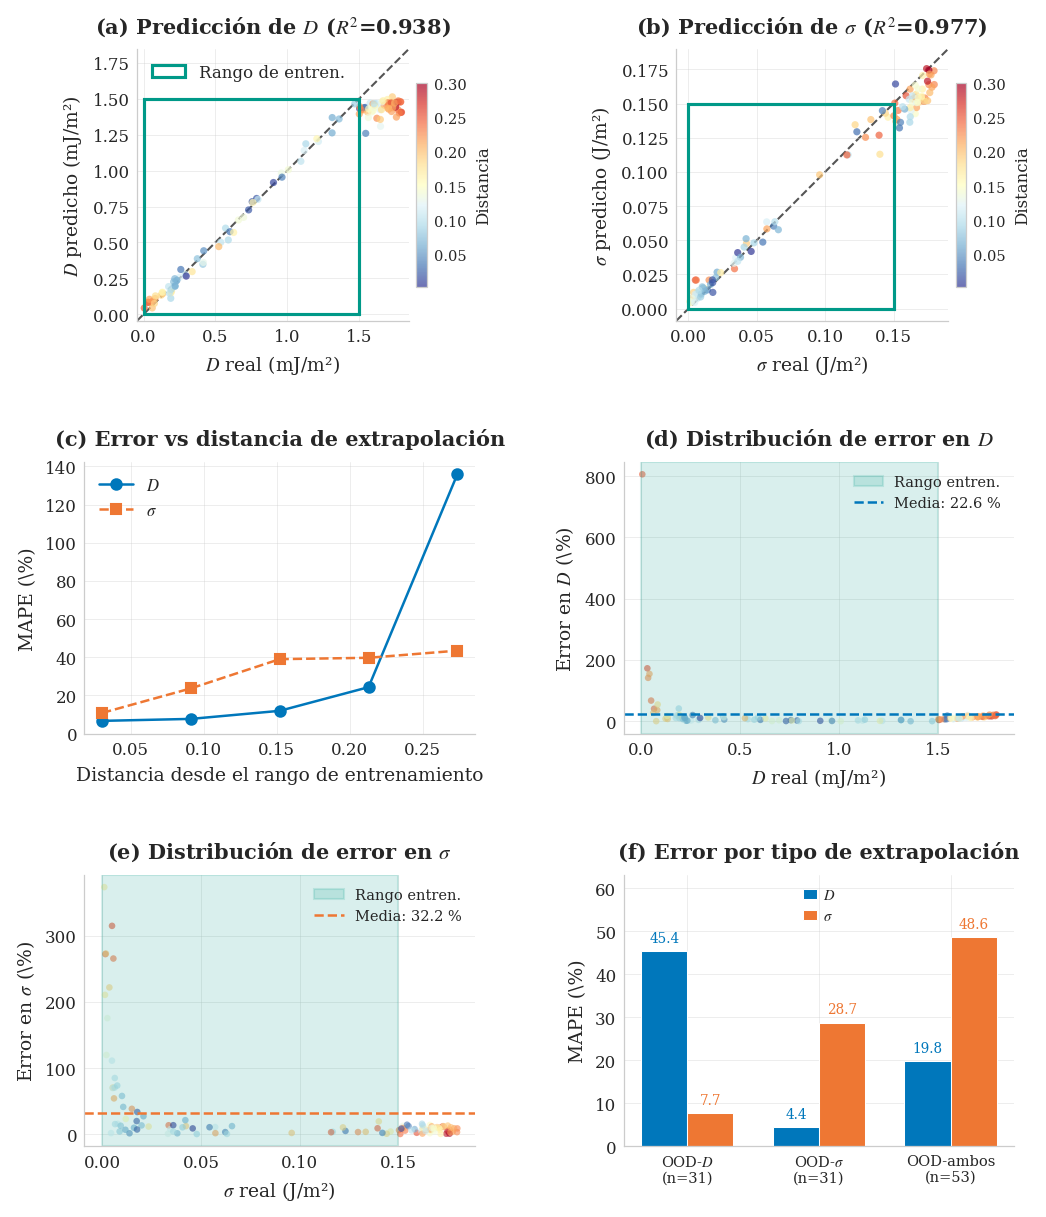


✓ Evaluación OOD guardada:
   PNG: outputs_improved_pinn_thank_god/improved_pinn_spectral_10_features_0.8weigth_physics_allimgs_DSigmafromzero(2613imgs)/figures/ood_evaluation_improved_pinn_spectral_10_features_0.8weigth_physics_allimgs_DSigmafromzero(2613imgs).png
   PDF: outputs_improved_pinn_thank_god/improved_pinn_spectral_10_features_0.8weigth_physics_allimgs_DSigmafromzero(2613imgs)/figures/ood_evaluation_improved_pinn_spectral_10_features_0.8weigth_physics_allimgs_DSigmafromzero(2613imgs).pdf

RESUMEN DE EVALUACIÓN FUERA DE DISTRIBUCIÓN (OOD)
Categoría       n        MAPE D (%)      MAPE σ (%)     
-----------------------------------------------------------------
OOD-D           31       45.44           7.70           
OOD-sigma       31       4.43            28.72          
OOD-ambos       53       19.81           48.59          
-----------------------------------------------------------------
Total           115      22.57           32.21          

\begin{table}[htbp]
\cent

In [64]:
# ==============================================================================
# OOD EVALUATION VISUALIZATION (Thesis-ready) - CORRECTED
# ==============================================================================

# =============================================================================
# RANGOS DE ENTRENAMIENTO CORRECTOS
# =============================================================================
TRAIN_D_MIN = 0.0         # J/m² (0.0 mJ/m²)
TRAIN_D_MAX = 1.5e-3      # J/m² (1.5 mJ/m²)
TRAIN_SIGMA_MIN = 0.0     # J/m²
TRAIN_SIGMA_MAX = 0.15    # J/m²

# =============================================================================
# Style setup (consistent with other figures)
# =============================================================================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Liberation Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.6,
    'grid.linewidth': 0.4,
    'grid.alpha': 0.4,
})

# Colors (consistent palette)
COLORS = {
    'D': '#0077BB',           # Azul para D
    'sigma': '#EE7733',       # Naranja para σ  
    'train_range': '#009988', # Verde azulado para rango de entrenamiento
    'reference': '#555555',   # Gris para referencias
}
CMAP = 'RdYlBu_r'  # Colormap: azul=cerca, rojo=lejos

# =============================================================================
# Create figure
# =============================================================================
fig = plt.figure(figsize=(8, 9.5))
gs = fig.add_gridspec(3, 2, hspace=0.52, wspace=0.38)

# Color by distance from training
colors = total_dist

# -----------------------------------------------------------------------------
# (a) D prediction scatter
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[0, 0])

sc = ax.scatter(D_true_ood * 1e3, D_pred_ood * 1e3, c=colors, cmap=CMAP, 
                s=12, alpha=0.7, edgecolors='none', rasterized=True)

d_min = min(D_true_ood.min(), D_pred_ood.min()) * 1e3 - 0.05
d_max = max(D_true_ood.max(), D_pred_ood.max()) * 1e3 + 0.05
ax.plot([d_min, d_max], [d_min, d_max], '--', color=COLORS['reference'], 
        linewidth=1.0, zorder=0)

# Training range box - CORREGIDO
rect = plt.Rectangle((TRAIN_D_MIN * 1e3, TRAIN_D_MIN * 1e3),  # origen (0, 0) en mJ/m²
                      (TRAIN_D_MAX - TRAIN_D_MIN) * 1e3,       # ancho: 1.5 mJ/m²
                      (TRAIN_D_MAX - TRAIN_D_MIN) * 1e3,       # alto: 1.5 mJ/m²
                      fill=False, edgecolor=COLORS['train_range'], linewidth=1.5, 
                      linestyle='-', label='Rango de entren.', zorder=5)
ax.add_patch(rect)

ax.set_xlabel('$D$ real (mJ/m²)')
ax.set_ylabel('$D$ predicho (mJ/m²)')
ax.set_title(f'(a) Predicción de $D$ ($R^2$={r2_D_ood:.3f})', fontweight='semibold', pad=8)
ax.legend(loc='upper left', framealpha=0.95, edgecolor='0.8')
ax.set_xlim([d_min, d_max])
ax.set_ylim([d_min, d_max])
ax.set_aspect('equal', adjustable='box')

# Colorbar
cbar = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label('Distancia', fontsize=8)
cbar.ax.tick_params(labelsize=7)

# -----------------------------------------------------------------------------
# (b) σ prediction scatter
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[0, 1])

sc = ax.scatter(s_true_ood, s_pred_ood, c=colors, cmap=CMAP,
                s=12, alpha=0.7, edgecolors='none', rasterized=True)

s_min = min(s_true_ood.min(), s_pred_ood.min()) - 0.01
s_max = max(s_true_ood.max(), s_pred_ood.max()) + 0.01
ax.plot([s_min, s_max], [s_min, s_max], '--', color=COLORS['reference'], 
        linewidth=1.0, zorder=0)

# Training range box - CORREGIDO
rect = plt.Rectangle((TRAIN_SIGMA_MIN, TRAIN_SIGMA_MIN),  # origen (0, 0)
                      TRAIN_SIGMA_MAX - TRAIN_SIGMA_MIN,   # ancho: 0.15
                      TRAIN_SIGMA_MAX - TRAIN_SIGMA_MIN,   # alto: 0.15
                      fill=False, edgecolor=COLORS['train_range'], linewidth=1.5, 
                      linestyle='-', zorder=5)
ax.add_patch(rect)

ax.set_xlabel('$\\sigma$ real (J/m²)')
ax.set_ylabel('$\\sigma$ predicho (J/m²)')
ax.set_title(f'(b) Predicción de $\\sigma$ ($R^2$={r2_s_ood:.3f})', fontweight='semibold', pad=8)
ax.set_xlim([s_min, s_max])
ax.set_ylim([s_min, s_max])
ax.set_aspect('equal', adjustable='box')

cbar = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label('Distancia', fontsize=8)
cbar.ax.tick_params(labelsize=7)

# -----------------------------------------------------------------------------
# (c) MAPE vs Distance from Training
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[1, 0])

valid_D = ~np.isnan(D_mape_by_total)
valid_s = ~np.isnan(s_mape_by_total)

if np.any(valid_D):
    ax.plot(np.array(total_bin_centers)[valid_D], np.array(D_mape_by_total)[valid_D], 
            'o-', linewidth=1.2, markersize=5, color=COLORS['D'], label='$D$')
if np.any(valid_s):
    ax.plot(np.array(total_bin_centers)[valid_s], np.array(s_mape_by_total)[valid_s], 
            's--', linewidth=1.2, markersize=5, color=COLORS['sigma'], label='$\\sigma$')

ax.set_xlabel('Distancia desde el rango de entrenamiento')
ax.set_ylabel('MAPE (\\%)')
ax.set_title('(c) Error vs distancia de extrapolación', fontweight='semibold', pad=8)
ax.legend(loc='upper left', framealpha=0.95, edgecolor='0.8')
ax.set_ylim(bottom=0)

# -----------------------------------------------------------------------------
# (d) D error vs true D
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[1, 1])

ax.scatter(D_true_ood * 1e3, D_error_pct, c=colors, cmap=CMAP, 
           s=10, alpha=0.6, edgecolors='none', rasterized=True)

# Training range shading - CORREGIDO
ax.axvspan(TRAIN_D_MIN * 1e3, TRAIN_D_MAX * 1e3, alpha=0.15, 
           color=COLORS['train_range'], label='Rango entren.')
ax.axhline(overall_D_mape, color=COLORS['D'], linestyle='--', linewidth=1.2, 
           label=f'Media: {overall_D_mape:.1f} %')

ax.set_xlabel('$D$ real (mJ/m²)')
ax.set_ylabel('Error en $D$ (\\%)')
ax.set_title('(d) Distribución de error en $D$', fontweight='semibold', pad=8)
ax.legend(loc='upper right', framealpha=0.95, edgecolor='0.8', fontsize=7)

# -----------------------------------------------------------------------------
# (e) σ error vs true σ
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[2, 0])

ax.scatter(s_true_ood, sigma_error_pct, c=colors, cmap=CMAP, 
           s=10, alpha=0.6, edgecolors='none', rasterized=True)

# Training range shading - CORREGIDO
ax.axvspan(TRAIN_SIGMA_MIN, TRAIN_SIGMA_MAX, alpha=0.15, 
           color=COLORS['train_range'], label='Rango entren.')
ax.axhline(overall_s_mape, color=COLORS['sigma'], linestyle='--', linewidth=1.2,
           label=f'Media: {overall_s_mape:.1f} %')

ax.set_xlabel('$\\sigma$ real (J/m²)')
ax.set_ylabel('Error en $\\sigma$ (\\%)')
ax.set_title('(e) Distribución de error en $\\sigma$', fontweight='semibold', pad=8)
ax.legend(loc='upper right', framealpha=0.95, edgecolor='0.8', fontsize=7)

# -----------------------------------------------------------------------------
# (f) MAPE by Category (bar chart) - LEYENDA CORREGIDA
# -----------------------------------------------------------------------------
ax = fig.add_subplot(gs[2, 1])

cat_order = ['ID', 'OOD-D', 'OOD-σ', 'OOD-both']
cat_labels_display = ['ID', 'OOD-$D$', 'OOD-$\\sigma$', 'OOD-ambos']
cat_D_mape = []
cat_s_mape = []
cat_labels = []
cat_labels_plot = []
cat_counts = []

for cat, cat_disp in zip(cat_order, cat_labels_display):
    mask = np.array([c == cat for c in categories])
    if mask.sum() > 0:
        cat_labels.append(cat)
        cat_labels_plot.append(cat_disp)
        cat_counts.append(mask.sum())
        cat_D_mape.append(D_error_pct[mask].mean())
        cat_s_mape.append(sigma_error_pct[mask].mean())

if len(cat_labels) > 0:
    x = np.arange(len(cat_labels))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, cat_D_mape, width, label='$D$', 
                   color=COLORS['D'], edgecolor='white', linewidth=0.5)
    bars2 = ax.bar(x + width/2, cat_s_mape, width, label='$\\sigma$', 
                   color=COLORS['sigma'], edgecolor='white', linewidth=0.5)
    
    # X-axis labels with counts
    ax.set_xticks(x)
    ax.set_xticklabels([f'{l}\n(n={n})' for l, n in zip(cat_labels_plot, cat_counts)], 
                       fontsize=7)
    
    # Value labels on bars
    for bar, val in zip(bars1, cat_D_mape):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1.5, 
                f'{val:.1f}', ha='center', va='bottom', fontsize=6.5, 
                color=COLORS['D'], fontweight='medium')
    for bar, val in zip(bars2, cat_s_mape):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=6.5,
                color=COLORS['sigma'], fontweight='medium')

ax.set_ylabel('MAPE (\\%)')
ax.set_title('(f) Error por tipo de extrapolación', fontweight='semibold', pad=8)

# LEYENDA CORREGIDA - en esquina superior derecha, más compacta
ax.legend(loc='upper center', framealpha=0.95, edgecolor='0.8',
          fontsize=7, handlelength=1.0, handletextpad=0.4)

# Aumentar espacio arriba para labels Y asegurar que leyenda no se solape
if len(cat_D_mape) > 0:
    max_val = max(max(cat_D_mape), max(cat_s_mape))
    ax.set_ylim(0, max_val * 1.30)  # 30% extra de espacio arriba

# =============================================================================
# Save
# =============================================================================
plt.tight_layout()

fig_path = FIG_DIR / f"ood_evaluation_{RUN_TAG}.png"
pdf_path = FIG_DIR / f"ood_evaluation_{RUN_TAG}.pdf"

plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig(pdf_path, format='pdf', bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✓ Evaluación OOD guardada:")
print(f"   PNG: {fig_path}")
print(f"   PDF: {pdf_path}")

# =============================================================================
# Summary table
# =============================================================================
print(f"\n{'='*65}")
print(f"RESUMEN DE EVALUACIÓN FUERA DE DISTRIBUCIÓN (OOD)")
print(f"{'='*65}")
print(f"{'Categoría':<15} {'n':<8} {'MAPE D (%)':<15} {'MAPE σ (%)':<15}")
print(f"{'-'*65}")
for cat, n, d_mape, s_mape in zip(cat_labels_plot, cat_counts, cat_D_mape, cat_s_mape):
    cat_clean = cat.replace('$', '').replace('\\', '')
    print(f"{cat_clean:<15} {n:<8} {d_mape:<15.2f} {s_mape:<15.2f}")
print(f"{'-'*65}")
print(f"{'Total':<15} {len(D_true_ood):<8} {overall_D_mape:<15.2f} {overall_s_mape:<15.2f}")
print(f"{'='*65}")

# LaTeX table
print(f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{Desempeño de generalización fuera de distribución (OOD). ID: dentro de distribución, 
          OOD-$D$: solo $D$ fuera de rango, OOD-$\\sigma$: solo $\\sigma$ fuera de rango, 
          OOD-ambos: ambos parámetros fuera de rango.}}
\\label{{tab:ood_results}}
\\begin{{tabular}}{{lccc}}
\\toprule
Categoría & $n$ & MAPE $D$ (\\%) & MAPE $\\sigma$ (\\%) \\\\
\\midrule""")
for cat, n, d_mape, s_mape in zip(cat_labels_plot, cat_counts, cat_D_mape, cat_s_mape):
    cat_latex = cat.replace('OOD-$D$', 'OOD-$D$').replace('OOD-$\\sigma$', 'OOD-$\\sigma$')
    print(f"{cat_latex} & {n} & {d_mape:.1f} & {s_mape:.1f} \\\\")
print(f"""\\midrule
Total & {len(D_true_ood)} & {overall_D_mape:.1f} & {overall_s_mape:.1f} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
""")

In [26]:

# ==============================================================================
# CELL 23: COMPARISON TABLE (for thesis)
# ==============================================================================

print("\n" + "="*70)
print("SUMMARY TABLE FOR THESIS")
print("="*70)
print(f"\n{'Category':<15} {'N':>5} {'D MAPE':>10} {'σ MAPE':>10} {'Avg Distance':>12}")
print("-"*55)

for cat in ['ID', 'OOD-D', 'OOD-σ', 'OOD-both', 'ALL']:
    if cat == 'ALL':
        mask = np.ones(len(categories), dtype=bool)
    else:
        mask = np.array([c == cat for c in categories])
    
    if mask.sum() > 0:
        d_mape = D_error_pct[mask].mean()
        s_mape = sigma_error_pct[mask].mean()
        avg_dist = total_dist[mask].mean()
        print(f"{cat:<15} {mask.sum():>5} {d_mape:>9.1f}% {s_mape:>9.1f}% {avg_dist:>12.3f}")

print("-"*55)

# Also print the in-distribution performance from training
print(f"\n(Training validation: D MAPE ≈ 3.3%, σ MAPE ≈ 7.6%)")

print("\n" + "="*70)
print("KEY FINDING FOR THESIS:")
print("="*70)
print("""
Compare the OOD-D and OOD-σ MAPE values above with:
1. Your training validation MAPE (3.3% D, 7.6% σ)
2. A baseline CNN trained without physics (run separately)

If the PINN shows better OOD performance than baseline, this demonstrates
that physics constraints improve extrapolation capability.
""")


SUMMARY TABLE FOR THESIS

Category            N     D MAPE     σ MAPE Avg Distance
-------------------------------------------------------
OOD-D              31      65.1%       7.8%        0.126
OOD-σ              31       3.2%      20.9%        0.097
OOD-both           53      16.3%      31.3%        0.191
ALL               115      25.9%      22.2%        0.148
-------------------------------------------------------

(Training validation: D MAPE ≈ 3.3%, σ MAPE ≈ 7.6%)

KEY FINDING FOR THESIS:

Compare the OOD-D and OOD-σ MAPE values above with:
1. Your training validation MAPE (3.3% D, 7.6% σ)
2. A baseline CNN trained without physics (run separately)

If the PINN shows better OOD performance than baseline, this demonstrates
that physics constraints improve extrapolation capability.



In [ ]:
# ==============================================================================
# ABLATION STUDY: Con vs Sin Pérdida Espectral
# ==============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
from sklearn.metrics import r2_score

# =============================================================================
# CONFIGURACIONES PARA ABLATION
# =============================================================================

ABLATION_CONFIGS = {
    'baseline_regression_only': {
        'description': 'Solo pérdida de regresión (sin física)',
        'loss_weights': {
            'regression': 1.0,
            'energy_ratio': 0.0,
            'spectral': 0.0
        },
        'use_annealing': False,
    },
    'with_spectral_physics': {
        'description': 'Regresión + Pérdida espectral calibrada',
        'loss_weights': {
            'regression': 1.0,
            'energy_ratio': 0.0,
            'spectral': 0.8
        },
        'use_annealing': True,
    }
}

ABLATION_EPOCHS = 100
ABLATION_WARMUP = 20

# =============================================================================
# FUNCIÓN DE ENTRENAMIENTO PARA ABLATION
# =============================================================================

def train_ablation_model(config_name, config, train_loader, val_loader, 
                         phys_params, phys_derived, target_mean, target_std,
                         epochs=ABLATION_EPOCHS, device='cuda'):
    """
    Entrena un modelo con una configuración específica de pérdida.
    """
    print(f"\n{'='*60}")
    print(f"ABLATION: {config_name}")
    print(f"Descripción: {config['description']}")
    print(f"{'='*60}")
    
    # Crear modelo fresco
    model = ImprovedPINN().to(device)
    
    # Crear criterion con los pesos de esta configuración
    criterion = ImprovedPhysicsLoss(
        phys_params=phys_params,
        phys_derived=phys_derived,
        loss_weights=config['loss_weights'],
        target_mean=target_mean,
        target_std=target_std,
        use_energy_loss=False
    )
    
    # Annealer solo si está habilitado
    annealer = None
    if config['use_annealing']:
        annealer = LossAnnealer(
            final_weights=config['loss_weights'],
            warmup_epochs=ABLATION_WARMUP,
            schedule='linear'
        )
    
    # Optimizer y scheduler
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )
    
    # Mixed precision
    scaler = torch.amp.GradScaler('cuda')
    use_amp = True
    
    # Tensores de normalización
    t_mean_t = torch.tensor(target_mean, dtype=torch.float32)
    t_std_t = torch.tensor(target_std, dtype=torch.float32)
    
    # Historia
    history = {
        'train_loss': [], 'val_loss': [],
        'val_mape_D': [], 'val_mape_sigma': [],
        'lr': []
    }
    
    best_val_loss = float('inf')
    best_model_state = None
    
    # Training loop
    for epoch in range(1, epochs + 1):
        
        # Update weights if annealing
        if annealer is not None:
            current_weights = annealer.get_weights(epoch, epochs)
            criterion.weights = current_weights
        
        # === TRAIN ===
        model.train()
        train_loss_sum = 0.0
        n_train = 0
        
        for imgs, m_fields, targets, run_ids in train_loader:
            imgs = imgs.to(device)
            targets = targets.to(device)
            if m_fields is not None:
                m_fields = {k: v.to(device) for k, v in m_fields.items()}
            
            optimizer.zero_grad()
            
            with torch.amp.autocast('cuda', enabled=use_amp):
                outputs = model(imgs)
                total_loss, _ = criterion(outputs, targets, m_fields, imgs)
            
            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            
            train_loss_sum += total_loss.item()
            n_train += 1
        
        epoch_train_loss = train_loss_sum / n_train
        history['train_loss'].append(epoch_train_loss)
        
        # === VALIDATION ===
        model.eval()
        val_loss_sum = 0.0
        n_val = 0
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for imgs, m_fields, targets, run_ids in val_loader:
                imgs = imgs.to(device)
                targets = targets.to(device)
                if m_fields is not None:
                    m_fields = {k: v.to(device) for k, v in m_fields.items()}
                
                with torch.amp.autocast('cuda', enabled=use_amp):
                    outputs = model(imgs)
                    total_loss, _ = criterion(outputs, targets, m_fields, imgs)
                
                val_loss_sum += total_loss.item()
                n_val += 1
                
                preds_unnorm = outputs.cpu() * t_std_t + t_mean_t
                targets_unnorm = targets.cpu() * t_std_t + t_mean_t
                all_preds.append(preds_unnorm)
                all_targets.append(targets_unnorm)
        
        epoch_val_loss = val_loss_sum / n_val
        history['val_loss'].append(epoch_val_loss)
        
        # Compute MAPE
        all_preds = torch.cat(all_preds)
        all_targets = torch.cat(all_targets)
        
        D_pred, D_true = all_preds[:, 0], all_targets[:, 0]
        s_pred, s_true = all_preds[:, 1], all_targets[:, 1]
        
        D_mask = D_true > 0.05e-3
        s_mask = s_true > 0.005
        
        mape_D = torch.mean(torch.abs((D_pred[D_mask] - D_true[D_mask]) / D_true[D_mask])).item() * 100
        mape_s = torch.mean(torch.abs((s_pred[s_mask] - s_true[s_mask]) / s_true[s_mask])).item() * 100
        
        history['val_mape_D'].append(mape_D)
        history['val_mape_sigma'].append(mape_s)
        
        # Scheduler & save best
        scheduler.step(epoch_val_loss)
        history['lr'].append(optimizer.param_groups[0]['lr'])
        
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_state = model.state_dict().copy()
        
        if epoch % 20 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d} | Train: {epoch_train_loss:.4e} | "
                  f"Val: {epoch_val_loss:.4e} | D: {mape_D:.1f}% | σ: {mape_s:.1f}%")
    
    # Restore best model and compute final metrics
    model.load_state_dict(best_model_state)
    model.eval()
    
    all_preds, all_targets = [], []
    with torch.no_grad():
        for imgs, m_fields, targets, run_ids in val_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds_unnorm = outputs.cpu() * t_std_t + t_mean_t
            targets_unnorm = targets.cpu() * t_std_t + t_mean_t
            all_preds.append(preds_unnorm)
            all_targets.append(targets_unnorm)
    
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    
    final_metrics = {
        'mape_D': history['val_mape_D'][-1],
        'mape_sigma': history['val_mape_sigma'][-1],
        'r2_D': r2_score(all_targets[:, 0], all_preds[:, 0]),
        'r2_sigma': r2_score(all_targets[:, 1], all_preds[:, 1]),
        'best_val_loss': best_val_loss
    }
    
    print(f"\n  ✓ Finalizado: MAPE_D={final_metrics['mape_D']:.2f}%, "
          f"MAPE_σ={final_metrics['mape_sigma']:.2f}%, "
          f"R²_D={final_metrics['r2_D']:.4f}, R²_σ={final_metrics['r2_sigma']:.4f}")
    
    return {
        'config': config,
        'history': history,
        'metrics': final_metrics,
        'model_state': best_model_state
    }


# =============================================================================
# EJECUTAR ABLATION STUDY
# =============================================================================

def run_full_ablation(save_dir=None):
    """Ejecuta el ablation study completo."""
    
    if save_dir is None:
        save_dir = FIG_DIR / 'ablation'
    save_dir = Path(save_dir)
    save_dir.mkdir(exist_ok=True, parents=True)
    
    results = {}
    
    for config_name, config in ABLATION_CONFIGS.items():
        result = train_ablation_model(
            config_name=config_name,
            config=config,
            train_loader=train_loader,
            val_loader=val_loader,
            phys_params=PHYS_PARAMS,
            phys_derived=PHYS_DERIVED,
            target_mean=t_mean,
            target_std=t_std,
            epochs=ABLATION_EPOCHS,
            device=device
        )
        results[config_name] = result
        
        # Guardar checkpoint
        torch.save({
            'model_state_dict': result['model_state'],
            'history': result['history'],
            'metrics': result['metrics'],
            'config': result['config']
        }, save_dir / f"ablation_{config_name}.pt")
    
    # Guardar resumen JSON
    summary = {
        name: {k: float(v) for k, v in r['metrics'].items()}
        for name, r in results.items()
    }
    with open(save_dir / 'ablation_summary.json', 'w') as f:
        json.dump(summary, f, indent=2)
    
    print(f"\n✓ Resultados guardados en: {save_dir}")
    
    return results


# =============================================================================
# VISUALIZACIÓN
# =============================================================================

def plot_ablation_comparison(results, save_path=None):
    """Genera figura comparativa thesis-ready."""
    
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update({
        'font.family': 'serif',
        'font.size': 9,
        'axes.titlesize': 10,
        'axes.labelsize': 9,
    })
    
    fig, axes = plt.subplots(1, 3, figsize=(8, 3))
    
    configs = list(results.keys())
    labels = ['Solo Regresión', '+ Física Espectral']
    colors = ['#888888', '#009988']
    
    # (a) MAPE
    ax = axes[0]
    x = np.arange(2)
    width = 0.35
    
    mape_D = [results[c]['metrics']['mape_D'] for c in configs]
    mape_s = [results[c]['metrics']['mape_sigma'] for c in configs]
    
    bars1 = ax.bar(x - width/2, mape_D, width, label='$D$', color='#0077BB', edgecolor='white')
    bars2 = ax.bar(x + width/2, mape_s, width, label='$\\sigma$', color='#EE7733', edgecolor='white')
    
    ax.set_ylabel('MAPE (\\%)')
    ax.set_title('(a) Error porcentual', fontweight='semibold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.legend(loc='upper right', fontsize=7)
    
    for bars, vals in [(bars1, mape_D), (bars2, mape_s)]:
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{val:.1f}', ha='center', fontsize=7)
    
    # (b) R²
    ax = axes[1]
    r2_D = [results[c]['metrics']['r2_D'] for c in configs]
    r2_s = [results[c]['metrics']['r2_sigma'] for c in configs]
    
    bars1 = ax.bar(x - width/2, r2_D, width, label='$D$', color='#0077BB', edgecolor='white')
    bars2 = ax.bar(x + width/2, r2_s, width, label='$\\sigma$', color='#EE7733', edgecolor='white')
    
    ax.set_ylabel('$R^2$')
    ax.set_title('(b) Coeficiente de determinación', fontweight='semibold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.legend(loc='lower right', fontsize=7)
    ax.set_ylim(0.9, 1.005)
    
    # (c) Convergencia
    ax = axes[2]
    for i, (c, label) in enumerate(zip(configs, labels)):
        h = results[c]['history']
        ax.semilogy(range(1, len(h['val_loss'])+1), h['val_loss'],
                    color=colors[i], linewidth=1.5, label=label)
    
    ax.set_xlabel('Época')
    ax.set_ylabel('Pérdida validación')
    ax.set_title('(c) Convergencia', fontweight='semibold')
    ax.legend(loc='upper right', fontsize=7)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Figura guardada: {save_path}")
    
    plt.show()
    return fig


# =============================================================================
# TABLA LATEX
# =============================================================================

def print_ablation_latex_table(results):
    """Imprime tabla LaTeX de resultados."""
    
    print(f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{Estudio de ablación: impacto de la pérdida espectral informada por física.}}
\\label{{tab:ablation}}
\\begin{{tabular}}{{lcccc}}
\\toprule
Configuración & MAPE $D$ (\\%) & MAPE $\\sigma$ (\\%) & $R^2_D$ & $R^2_\\sigma$ \\\\
\\midrule""")
    
    labels = {'baseline_regression_only': 'Solo regresión',
              'with_spectral_physics': '+ Pérdida espectral'}
    
    for config_name, r in results.items():
        m = r['metrics']
        label = labels.get(config_name, config_name)
        print(f"{label} & {m['mape_D']:.1f} & {m['mape_sigma']:.1f} & "
              f"{m['r2_D']:.3f} & {m['r2_sigma']:.3f} \\\\")
    
    # Calcular mejora
    base = results['baseline_regression_only']['metrics']
    phys = results['with_spectral_physics']['metrics']
    
    improv_D = (base['mape_D'] - phys['mape_D']) / base['mape_D'] * 100
    improv_s = (base['mape_sigma'] - phys['mape_sigma']) / base['mape_sigma'] * 100
    
    print(f"""\\midrule
Mejora relativa & {improv_D:+.1f}\\% & {improv_s:+.1f}\\% & -- & -- \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
""")


# =============================================================================
# EJECUTAR
# =============================================================================

if __name__ == "__main__" or True:  # Cambiar a False para no ejecutar automáticamente
    
    print("\n" + "="*70)
    print("ABLATION STUDY: Efecto de la pérdida espectral")
    print("="*70)
    
    # Ejecutar ablation
    # ablation_results = run_full_ablation(save_dir=FIG_DIR / 'ablation')
    
    # Visualizar
    # plot_ablation_comparison(ablation_results, save_path=FIG_DIR / 'ablation_comparison.png')
    
    # Tabla LaTeX
    # print_ablation_latex_table(ablation_results)
    
    print("\n⚠️ Descomenta las líneas anteriores para ejecutar el ablation study")
    print("   Tiempo estimado: ~3 horas (2 entrenamientos × 100 épocas)")